In [20]:
import itertools
import math
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LinearRegression


FEATURES = ("A", "B", "C", "D")
CLASS_COLUMN = "Class"
MISSING_RATES = (0, 1, 2, 5, 10, 20, 50, 80)
PALETTE = ("#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00")
MARKERS = ("o", "s", "^", "D", "P")


def configure_matplotlib(style):
    sns.set_theme(style="whitegrid" if style["grid"] else "white", context="notebook")
    plt.rcParams.update(
        {
            "font.size": style["font_size"],
            "axes.titlesize": style["title_size"],
            "axes.labelsize": style["label_size"],
            "figure.dpi": style["dpi"],
            "savefig.dpi": style["dpi"],
        }
    )


def style_axis(ax, style):
    for spine in ax.spines.values():
        spine.set_color(style["axis_color"])
        spine.set_linewidth(style["axis_linewidth"])
    ax.tick_params(
        axis="both",
        which="both",
        color=style["axis_color"],
        width=style["axis_linewidth"],
    )
    ax.xaxis.set_major_locator(MaxNLocator(style["major_ticks"]))
    ax.yaxis.set_major_locator(MaxNLocator(style["major_ticks"]))
    if style["minor_ticks"] > 0:
        ax.xaxis.set_minor_locator(AutoMinorLocator(style["minor_ticks"]))
        ax.yaxis.set_minor_locator(AutoMinorLocator(style["minor_ticks"]))
    ax.grid(style["grid"], which="major", alpha=0.25)
    ax.grid(style["grid"], which="minor", alpha=0.10)
    if style["square"]:
        try:
            ax.set_box_aspect(1)
        except AttributeError:
            pass


def save_figure(fig, path, style):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight", dpi=style["dpi"])
    display(fig)
    plt.close(fig)


In [21]:
# [1.1]
def generate_dfS00(n_objects=1000, n_classes=3, random_state=42):
    """Создать четыре нормальных признака, причём corr(A, B)=0.9."""

    if n_objects < n_classes or n_classes < 2:
        raise ValueError("Нужно не меньше объектов, чем классов, и минимум 2 класса")
    covariance = np.eye(4)
    covariance[0, 1] = covariance[1, 0] = 0.9
    rng = np.random.default_rng(random_state)
    values = rng.multivariate_normal(np.zeros(4), covariance, size=n_objects)

    labels = np.resize(np.arange(n_classes), n_objects)
    rng.shuffle(labels)
    frame = pd.DataFrame(values, columns=FEATURES)
    frame[CLASS_COLUMN] = pd.Categorical([f"class_{x + 1}" for x in labels])
    return frame


In [22]:
# [1.2]
def save_dataset_statistics(df, output_dir):
    tables = output_dir / "tables"
    tables.mkdir(parents=True, exist_ok=True)
    feature_df = df.loc[:, FEATURES]

    overview = pd.DataFrame(
        {
            "metric": [
                "objects",
                "feature_columns",
                "all_columns",
                "classes",
                "objects_with_NaN",
                "objects_with_zero",
            ],
            "value": [
                len(df),
                len(FEATURES),
                df.shape[1],
                df[CLASS_COLUMN].nunique(dropna=False),
                feature_df.isna().any(axis=1).sum(),
                feature_df.eq(0).any(axis=1).sum(),
            ],
        }
    )
    overview.to_csv(tables / "1_2_dataset_overview.csv", index=False)

    class_stats = (
        df.groupby(CLASS_COLUMN, observed=False)
        .apply(
            lambda part: pd.Series(
                {
                    "objects": len(part),
                    "objects_with_NaN": part.loc[:, FEATURES].isna().any(axis=1).sum(),
                    "objects_with_zero": part.loc[:, FEATURES].eq(0).any(axis=1).sum(),
                }
            ),
            include_groups=False,
        )
        .reset_index()
    )
    class_stats.to_csv(tables / "1_2_class_statistics.csv", index=False)

    statistics = feature_df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
    statistics["dtype"] = feature_df.dtypes.astype(str)
    statistics["missing"] = feature_df.isna().sum()
    statistics["zeros"] = feature_df.eq(0).sum()
    statistics["unique"] = feature_df.nunique(dropna=True)
    statistics["skew"] = feature_df.skew()
    statistics["kurtosis"] = feature_df.kurtosis()
    statistics.to_csv(tables / "1_2_feature_statistics.csv")


In [23]:
# [1.3]
def plot_rainclouds(df, path, style, seed):
    classes = [str(x) for x in df[CLASS_COLUMN].cat.categories]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    rng = np.random.default_rng(seed)

    for ax, feature in zip(axes.flat, FEATURES):
        groups = [
            df.loc[df[CLASS_COLUMN].astype(str) == class_name, feature].dropna().to_numpy()
            for class_name in classes
        ]
        positions = np.arange(len(classes))
        violins = ax.violinplot(
            groups,
            positions=positions,
            vert=False,
            widths=0.72,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )
        for position, body, color in zip(positions, violins["bodies"], PALETTE):
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.30)
            vertices = body.get_paths()[0].vertices
            vertices[:, 1] = np.maximum(vertices[:, 1], position)

        box = ax.boxplot(
            groups,
            positions=positions,
            vert=False,
            widths=0.13,
            patch_artist=True,
            showfliers=False,
            whis=(0, 100),
            medianprops={"color": "black", "linewidth": 1.5},
        )
        for patch, color in zip(box["boxes"], PALETTE):
            patch.set_facecolor(color)
            patch.set_alpha(0.65)

        for position, values, color in zip(positions, groups, PALETTE):
            jitter = position - 0.19 + rng.uniform(-0.05, 0.05, size=len(values))
            ax.scatter(values, jitter, s=7, color=color, alpha=0.25, linewidths=0)

        ax.set_yticks(positions, classes)
        ax.set_xlabel(feature)
        ax.set_ylabel(CLASS_COLUMN)
        if style["show_title"]:
            ax.set_title(f"{feature}: median, IQR и range")
        style_axis(ax, style)

    save_figure(fig, path, style)


In [24]:
# [1.4]
def plot_pairwise(df, path, style):
    n = len(FEATURES)
    classes = [str(x) for x in df[CLASS_COLUMN].cat.categories]
    fig, axes = plt.subplots(n, n, figsize=(13, 13), constrained_layout=True)

    for row, y_feature in enumerate(FEATURES):
        for col, x_feature in enumerate(FEATURES):
            ax = axes[row, col]
            if row == col:
                for class_name, color in zip(classes, PALETTE):
                    values = df.loc[
                        df[CLASS_COLUMN].astype(str) == class_name, x_feature
                    ].dropna()
                    if len(values) > 1 and values.nunique() > 1:
                        grid = np.linspace(values.min(), values.max(), 160)
                        density = gaussian_kde(values)(grid)
                        ax.fill_between(grid, density, color=color, alpha=0.20)
                        ax.plot(grid, density, color=color, linewidth=1.3)
                ax.set_ylabel("density" if col == 0 else "")
            else:
                for class_name, color, marker in zip(classes, PALETTE, MARKERS):
                    mask = df[CLASS_COLUMN].astype(str) == class_name
                    ax.scatter(
                        df.loc[mask, x_feature],
                        df.loc[mask, y_feature],
                        s=style["point_size"],
                        alpha=style["alpha"],
                        c=color,
                        marker=marker,
                        edgecolors="none",
                    )
            if row == n - 1:
                ax.set_xlabel(x_feature)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)
            if col == 0 and row != col:
                ax.set_ylabel(y_feature)
            elif row != col:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)
            style_axis(ax, style)

    if style["show_title"]:
        fig.suptitle("[1.4] Попарные диаграммы и плотности по классам", fontsize=14)
    if style["show_legend"]:
        handles = [
            Line2D(
                [0],
                [0],
                marker=marker,
                linestyle="none",
                color=color,
                label=class_name,
                markersize=7,
            )
            for class_name, color, marker in zip(classes, PALETTE, MARKERS)
        ]
        fig.legend(handles=handles, loc="upper right", title=CLASS_COLUMN)
    save_figure(fig, path, style)


In [25]:
# [1.5]
def plot_correlations(
    df,
    path,
    style,
    methods=("pearson", "spearman"),
    title="Корреляции",
):
    groups = [("all", df)]
    groups.extend(
        (str(class_name), df.loc[df[CLASS_COLUMN].astype(str) == str(class_name)])
        for class_name in df[CLASS_COLUMN].cat.categories
    )
    fig, axes = plt.subplots(
        len(methods),
        len(groups),
        figsize=(4.0 * len(groups), 3.7 * len(methods)),
        squeeze=False,
        constrained_layout=True,
    )
    for row, method in enumerate(methods):
        for col, (group_name, group_df) in enumerate(groups):
            corr = group_df.loc[:, FEATURES].corr(method=method)
            sns.heatmap(
                corr,
                vmin=-1,
                vmax=1,
                center=0,
                cmap="vlag",
                annot=True,
                fmt=".2f",
                square=True,
                linewidths=0.5,
                cbar=col == len(groups) - 1,
                ax=axes[row, col],
            )
            axes[row, col].set_title(f"{method}: {group_name}")
    if style["show_title"]:
        fig.suptitle(title, fontsize=14)
    save_figure(fig, path, style)


def plot_correlation_comparison(
    datasets,
    path,
    style,
    title,
):
    """Собрать Pearson heatmap всех датасетов в одно сравнительное полотно."""

    first_df = next(iter(datasets.values()))
    class_names = [str(x) for x in first_df[CLASS_COLUMN].cat.categories]
    group_names = ["all", *class_names]
    fig, axes = plt.subplots(
        len(datasets),
        len(group_names),
        figsize=(3.8 * len(group_names), 3.45 * len(datasets)),
        squeeze=False,
        constrained_layout=True,
    )
    for row, (dataset_name, df) in enumerate(datasets.items()):
        groups = [("all", df)] + [
            (name, df.loc[df[CLASS_COLUMN].astype(str) == name]) for name in class_names
        ]
        for col, (group_name, group_df) in enumerate(groups):
            corr = group_df.loc[:, FEATURES].corr(method="pearson")
            sns.heatmap(
                corr,
                vmin=-1,
                vmax=1,
                center=0,
                cmap="vlag",
                annot=True,
                fmt=".2f",
                square=True,
                linewidths=0.4,
                cbar=row == 0 and col == len(groups) - 1,
                ax=axes[row, col],
            )
            axes[row, col].set_title(group_name if row == 0 else "")
            if col == 0:
                axes[row, col].set_ylabel(dataset_name)
            else:
                axes[row, col].set_ylabel("")
    if style["show_title"]:
        fig.suptitle(title, fontsize=14)
    save_figure(fig, path, style)


In [26]:
# [1.6]
def inject_mcar(df, percent, random_state):
    """Удалить ровно percent% случайных ячеек среди количественных признаков."""

    if not 0 <= percent <= 100:
        raise ValueError("percent должен лежать между 0 и 100")
    result = df.copy(deep=True)
    n_cells = len(result) * len(FEATURES)
    n_missing = round(n_cells * percent / 100)
    rng = np.random.default_rng(random_state)
    flat_positions = rng.choice(n_cells, size=n_missing, replace=False)
    rows, cols = np.divmod(flat_positions, len(FEATURES))
    for col_index, feature in enumerate(FEATURES):
        result.loc[rows[cols == col_index], feature] = np.nan
    return result


def plot_scatter_panel(
    datasets,
    pair,
    path,
    style,
    title,
):
    ncols = min(4, len(datasets))
    nrows = math.ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.1 * ncols, 4.0 * nrows),
        squeeze=False,
        constrained_layout=True,
    )
    for ax, (name, df) in zip(axes.flat, datasets.items()):
        classes = [str(x) for x in df[CLASS_COLUMN].cat.categories]
        for class_name, color, marker in zip(classes, PALETTE, MARKERS):
            mask = df[CLASS_COLUMN].astype(str) == class_name
            ax.scatter(
                df.loc[mask, pair[0]],
                df.loc[mask, pair[1]],
                s=style["point_size"],
                alpha=style["alpha"],
                color=color,
                marker=marker,
                edgecolors="none",
            )
        ax.set_xlabel(pair[0])
        ax.set_ylabel(pair[1])
        ax.set_title(name)
        style_axis(ax, style)
    for ax in axes.flat[len(datasets) :]:
        ax.set_visible(False)
    if style["show_title"]:
        fig.suptitle(title, fontsize=14)
    if style["show_legend"]:
        first_df = next(iter(datasets.values()))
        handles = [
            Line2D(
                [0], [0], marker=m, linestyle="none", color=c, label=str(k), markersize=6
            )
            for k, c, m in zip(first_df[CLASS_COLUMN].cat.categories, PALETTE, MARKERS)
        ]
        fig.legend(handles=handles, loc="upper right", title=CLASS_COLUMN)
    save_figure(fig, path, style)


In [27]:
# [1.7], [1.8]
def impute_dataset(
    df,
    method,
    random_state,
    knn_neighbors=5,
):
    result = df.copy(deep=True)
    if method == "median":
        imputer = SimpleImputer(strategy="median")
    elif method == "knn":
        imputer = KNNImputer(n_neighbors=knn_neighbors, weights="distance")
    elif method == "regression":
        imputer = IterativeImputer(
            estimator=LinearRegression(),
            initial_strategy="median",
            max_iter=10,
            imputation_order="ascending",
            sample_posterior=False,
            random_state=random_state,
        )
    elif method == "mice":
        imputer = IterativeImputer(
            estimator=BayesianRidge(),
            initial_strategy="median",
            max_iter=10,
            imputation_order="random",
            sample_posterior=True,
            random_state=random_state,
        )
    else:
        raise ValueError(f"Неизвестный метод импутации: {method}")
    result.loc[:, FEATURES] = imputer.fit_transform(result.loc[:, FEATURES])
    return result


def all_imputations(df, random_state, knn_neighbors):
    return {
        method: impute_dataset(df, method, random_state, knn_neighbors)
        for method in ("median", "knn", "regression", "mice")
    }


In [28]:
# [1.9]
def exact_pattern_counts(df, observed):
    membership = df.loc[:, FEATURES].notna() if observed else df.loc[:, FEATURES].isna()
    counts = membership.value_counts(sort=False)
    all_patterns = pd.MultiIndex.from_tuples(
        list(itertools.product([False, True], repeat=len(FEATURES))),
        names=FEATURES,
    )
    return counts.reindex(all_patterns, fill_value=0).sort_values(ascending=False)


def plot_upset(
    df,
    path,
    style,
    dataset_name,
    observed,
):
    """UpSet-style: столбцы размеров точных пересечений и матрица членства."""

    counts = exact_pattern_counts(df, observed=observed)
    fig = plt.figure(figsize=(13, 6), constrained_layout=True)
    grid = fig.add_gridspec(2, 1, height_ratios=(3.0, 1.7), hspace=0.03)
    ax_bar = fig.add_subplot(grid[0])
    ax_matrix = fig.add_subplot(grid[1], sharex=ax_bar)
    x = np.arange(len(counts))

    ax_bar.bar(x, counts.to_numpy(), color="#4C78A8", width=0.78)
    ax_bar.set_ylabel("objects")
    ax_bar.tick_params(labelbottom=False)
    for index, value in enumerate(counts.to_numpy()):
        if value > 0:
            ax_bar.text(index, value, str(int(value)), ha="center", va="bottom", fontsize=7)
    style_axis(ax_bar, style)
    ax_bar.set_box_aspect(None)

    patterns = list(counts.index)
    for col, pattern in enumerate(patterns):
        active = [row for row, flag in enumerate(pattern) if flag]
        if len(active) > 1:
            ax_matrix.plot([col, col], [min(active), max(active)], color="#222222", lw=1.2)
        for row, flag in enumerate(pattern):
            ax_matrix.scatter(
                col,
                row,
                s=30 if flag else 12,
                color="#222222" if flag else "#D9D9D9",
                zorder=3,
            )
    ax_matrix.set_yticks(np.arange(len(FEATURES)), FEATURES)
    ax_matrix.set_ylim(len(FEATURES) - 0.5, -0.5)
    ax_matrix.set_xticks(x)
    ax_matrix.set_xticklabels([str(i + 1) for i in x], fontsize=7)
    ax_matrix.set_xlabel("intersection pattern")
    ax_matrix.grid(False)
    ax_matrix.spines[["top", "right"]].set_visible(False)

    mode = "совместно присутствующие значения" if observed else "сочетания пропусков"
    if style["show_title"]:
        fig.suptitle(f"[1.9] {dataset_name}: {mode}", fontsize=14)
    save_figure(fig, path, style)


def plot_upset_comparison(
    datasets,
    path,
    style,
    observed,
    title,
):
    """Один UpSet-график с отдельной строкой размеров для каждого датасета."""

    raw_counts = {
        name: exact_pattern_counts(df, observed=observed) for name, df in datasets.items()
    }
    aggregate = sum(raw_counts.values())
    pattern_order = list(aggregate.sort_values(ascending=False).index)
    n_datasets = len(datasets)
    fig = plt.figure(
        figsize=(14, 1.45 * n_datasets + 3.0),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        n_datasets + 1,
        1,
        height_ratios=[1.2] * n_datasets + [2.0],
        hspace=0.03,
    )
    axes = [fig.add_subplot(grid[row]) for row in range(n_datasets + 1)]
    x = np.arange(len(pattern_order))

    for row, (name, counts) in enumerate(raw_counts.items()):
        ax = axes[row]
        values = counts.reindex(pattern_order).to_numpy()
        ax.bar(x, values, color="#4C78A8", width=0.78)
        ax.set_ylabel(name, rotation=0, ha="right", va="center")
        ax.tick_params(labelbottom=False)
        ax.set_xlim(-0.8, len(x) - 0.2)
        ax.grid(style["grid"], axis="y", alpha=0.20)
        ax.spines[["top", "right"]].set_visible(False)
        for index, value in enumerate(values):
            if value > 0:
                ax.text(index, value, str(int(value)), ha="center", va="bottom", fontsize=6)

    ax_matrix = axes[-1]
    for col, pattern in enumerate(pattern_order):
        active = [row for row, flag in enumerate(pattern) if flag]
        if len(active) > 1:
            ax_matrix.plot([col, col], [min(active), max(active)], color="#222222", lw=1.2)
        for row, flag in enumerate(pattern):
            ax_matrix.scatter(
                col,
                row,
                s=30 if flag else 12,
                color="#222222" if flag else "#D9D9D9",
                zorder=3,
            )
    ax_matrix.set_yticks(np.arange(len(FEATURES)), FEATURES)
    ax_matrix.set_ylim(len(FEATURES) - 0.5, -0.5)
    ax_matrix.set_xticks(x)
    ax_matrix.set_xticklabels([str(i + 1) for i in x], fontsize=7)
    ax_matrix.set_xlabel("intersection pattern")
    ax_matrix.grid(False)
    ax_matrix.spines[["top", "right"]].set_visible(False)
    if style["show_title"]:
        mode = "присутствующие значения" if observed else "сочетания пропусков"
        fig.suptitle(f"{title}: {mode}", fontsize=14)
    save_figure(fig, path, style)


def save_missingness_summary(datasets, output_path):
    rows = []
    for name, df in datasets.items():
        row = {
            "dataset": name,
            "missing_cells": int(df.loc[:, FEATURES].isna().sum().sum()),
            "rows_with_missing": int(df.loc[:, FEATURES].isna().any(axis=1).sum()),
        }
        row.update(
            {f"missing_{feature}": int(df[feature].isna().sum()) for feature in FEATURES}
        )
        rows.append(row)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(output_path, index=False)


def comparison_workflow(
    base_df,
    missing_df,
    base_name,
    missing_name,
    output_dir,
    style,
    random_state,
    knn_neighbors,
    pair1,
    pair2,
    task_prefix,
):
    imputations = all_imputations(missing_df, random_state, knn_neighbors)
    datasets = {
        base_name: base_df,
        missing_name: missing_df,
        **{f"{missing_name}_{name}": value for name, value in imputations.items()},
    }
    data_dir = output_dir / "data"
    figures = output_dir / "figures" / task_prefix
    for name, frame in datasets.items():
        frame.to_csv(data_dir / f"{name}.csv", index=False)

    plot_correlation_comparison(
        datasets,
        figures / "correlations_pearson.png",
        style,
        title=f"{task_prefix}: корреляции Пирсона",
    )
    plot_upset_comparison(
        datasets,
        figures / "upset_missing.png",
        style,
        observed=False,
        title=f"{task_prefix} UpSet",
    )
    plot_upset_comparison(
        datasets,
        figures / "upset_observed.png",
        style,
        observed=True,
        title=f"{task_prefix} UpSet",
    )

    plot_scatter_panel(
        datasets,
        pair1,
        figures / f"pair_{pair1[0]}_{pair1[1]}.png",
        style,
        f"{task_prefix}: сравнение {pair1[0]}+{pair1[1]}",
    )
    plot_scatter_panel(
        datasets,
        pair2,
        figures / f"pair_{pair2[0]}_{pair2[1]}.png",
        style,
        f"{task_prefix}: сравнение {pair2[0]}+{pair2[1]}",
    )
    save_missingness_summary(
        datasets, output_dir / "tables" / f"{task_prefix}_missingness.csv"
    )
    return datasets


In [29]:
# [1.10]
def inject_mnar(df):
    result = df.copy(deep=True)
    for feature in ("C", "D"):
        median = result[feature].median()
        result.loc[result[feature] < median, feature] = np.nan
    return result


In [30]:
seed = 42
objects = 1000
classes = 3
missing_rate = 20
knn_neighbors = 5
pair1 = ("A", "B")
pair2 = ("C", "D")

assert missing_rate in MISSING_RATES
assert len(pair1) == len(pair2) == 2
assert all(feature in FEATURES for feature in pair1 + pair2)

task_dir = Path.cwd()
if (task_dir / "task1" / "task1.ipynb").exists():
    task_dir = task_dir / "task1"
output_dir = task_dir / "results"
for subdir in ("data", "tables", "figures"):
    (output_dir / subdir).mkdir(parents=True, exist_ok=True)

style = {
    "axis_color": "#333333",
    "axis_linewidth": 0.9,
    "major_ticks": 6,
    "minor_ticks": 2,
    "grid": True,
    "square": True,
    "font_size": 9,
    "title_size": 11,
    "label_size": 10,
    "show_legend": True,
    "show_title": True,
    "alpha": 0.55,
    "point_size": 16.0,
    "dpi": 150,
}
configure_matplotlib(style)


In [31]:
# [1.1]--[1.2]
dfS00 = generate_dfS00(objects, classes, seed)
dfS00.to_csv(output_dir / "data" / "dfS00.csv", index=False)
save_dataset_statistics(dfS00, output_dir)
display(dfS00.head())
display(pd.read_csv(output_dir / "tables" / "1_2_class_statistics.csv"))


,A,B,C,D,Class
0,-0.507318,-0.086685,0.750451,-1.039984,class_3
1,1.972348,1.830920,0.127840,-1.302180,class_3
2,-0.157544,0.190295,0.879398,-0.853044,class_1
3,0.127785,-0.256502,0.467509,1.127241,class_2
4,-0.348250,-0.370578,0.878450,-0.958883,class_2


,Class,objects,objects_with_NaN,objects_with_zero
0,class_1,334,0,0
1,class_2,333,0,0
2,class_3,333,0,0


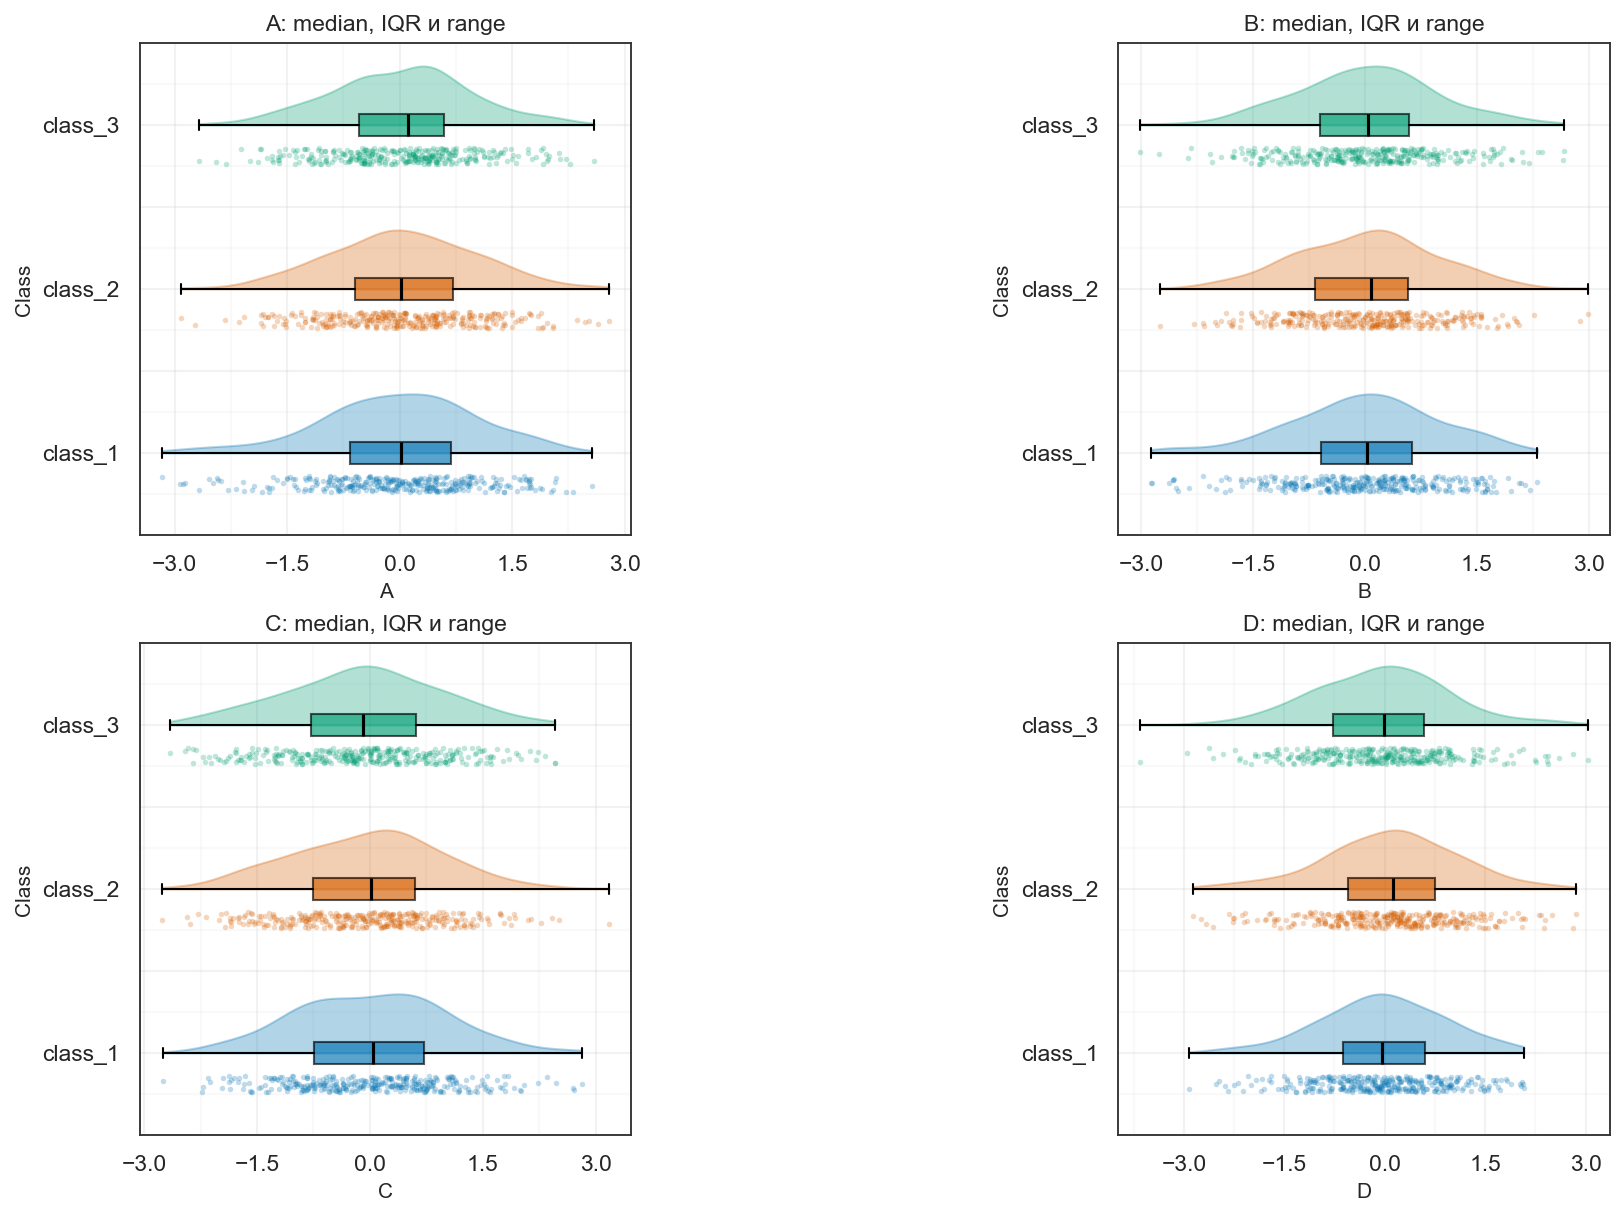

In [32]:
# [1.3]
plot_rainclouds(
    dfS00, output_dir / "figures" / "1_3_rainclouds.png", style, seed
)


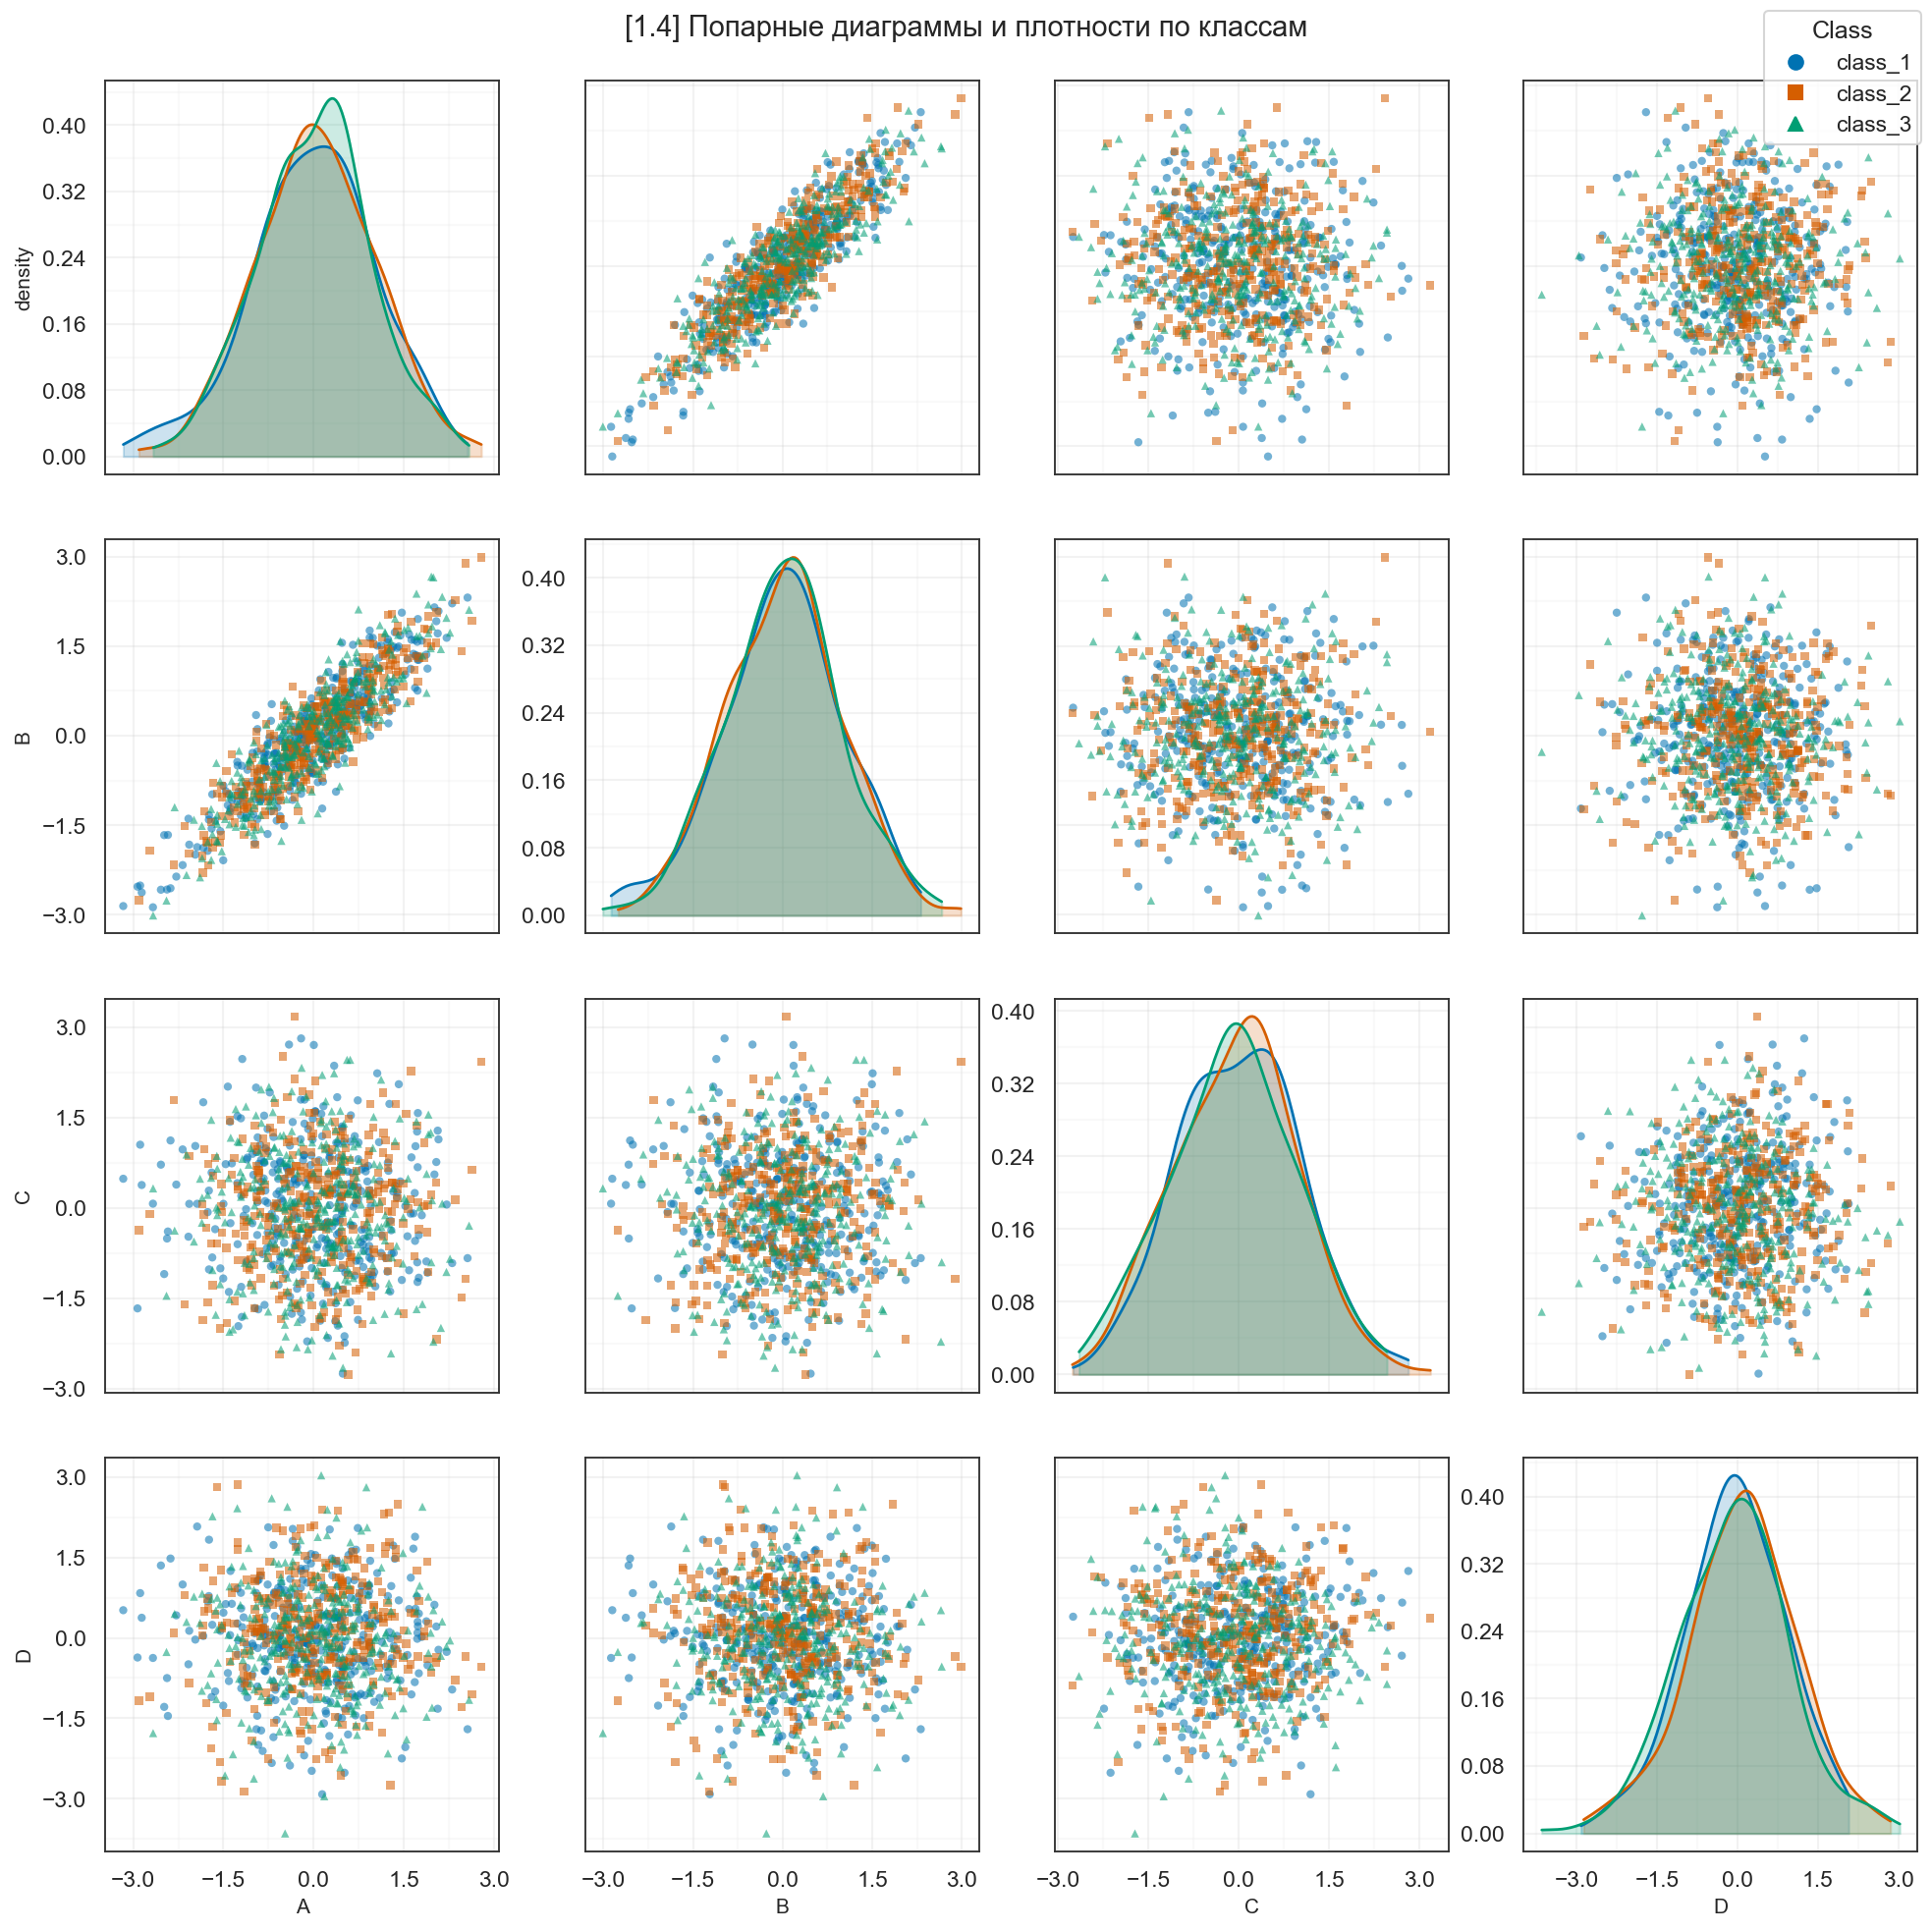

In [33]:
# [1.4]
plot_pairwise(dfS00, output_dir / "figures" / "1_4_pairwise.png", style)


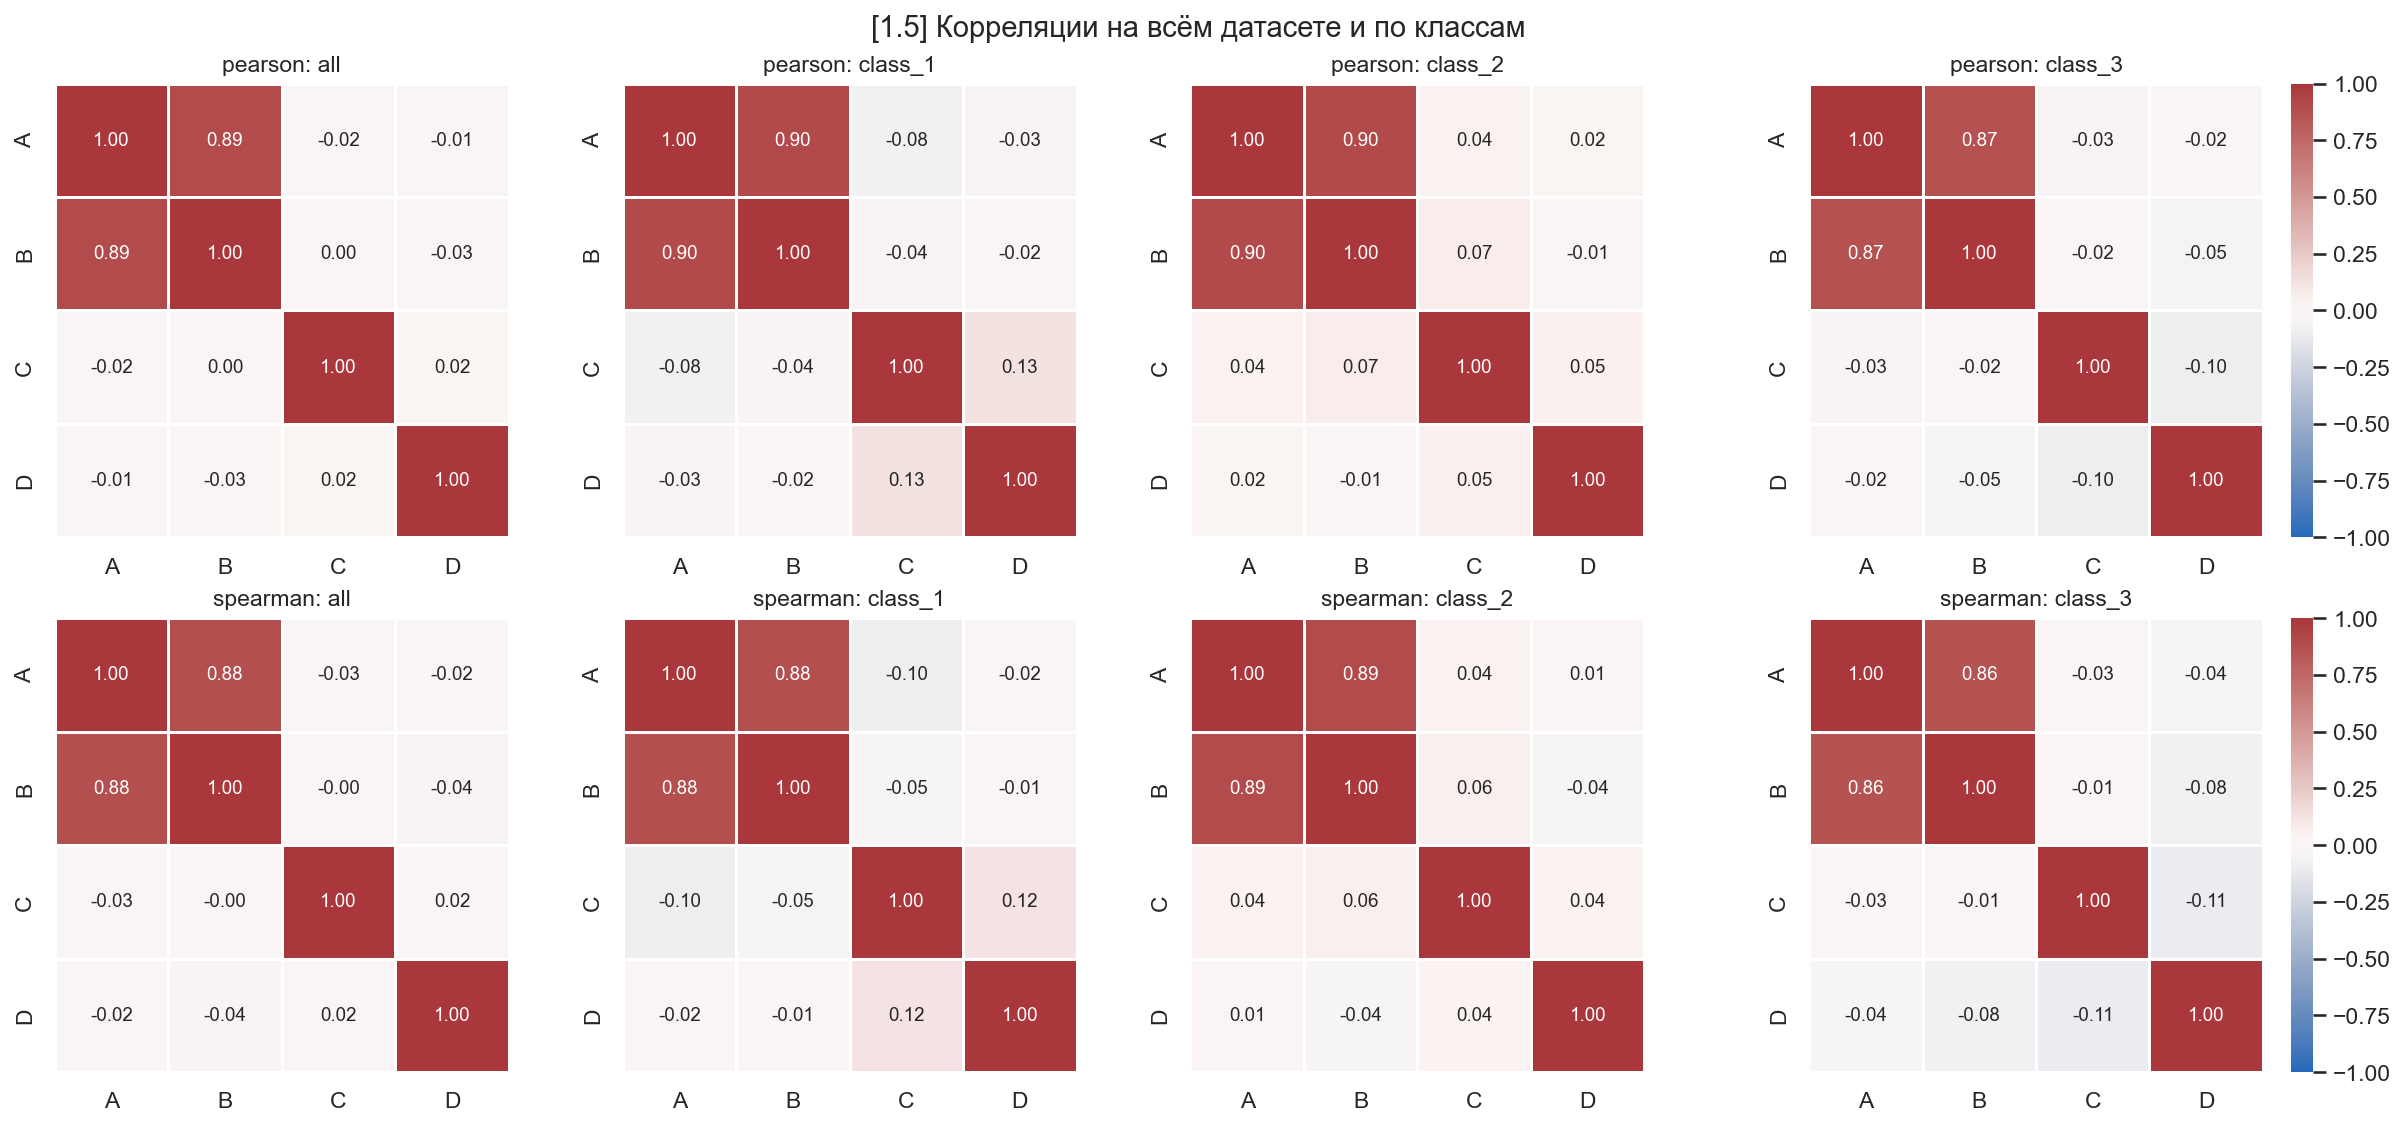

In [34]:
# [1.5]
plot_correlations(
    dfS00,
    output_dir / "figures" / "1_5_correlations.png",
    style,
    methods=("pearson", "spearman"),
    title="[1.5] Корреляции на всём датасете и по классам",
)


,dataset,missing_cells,rows_with_missing,missing_A,missing_B,missing_C,missing_D
0,dfSd00,0,0,0,0,0,0
1,dfSd01,40,40,11,8,10,11
2,dfSd02,80,76,25,18,18,19
3,dfSd05,200,180,58,57,44,41
4,dfSd10,400,339,97,111,85,107
5,dfSd20,800,592,193,198,204,205
6,dfSd50,2000,939,480,502,510,508
7,dfSd80,3200,999,810,786,796,808


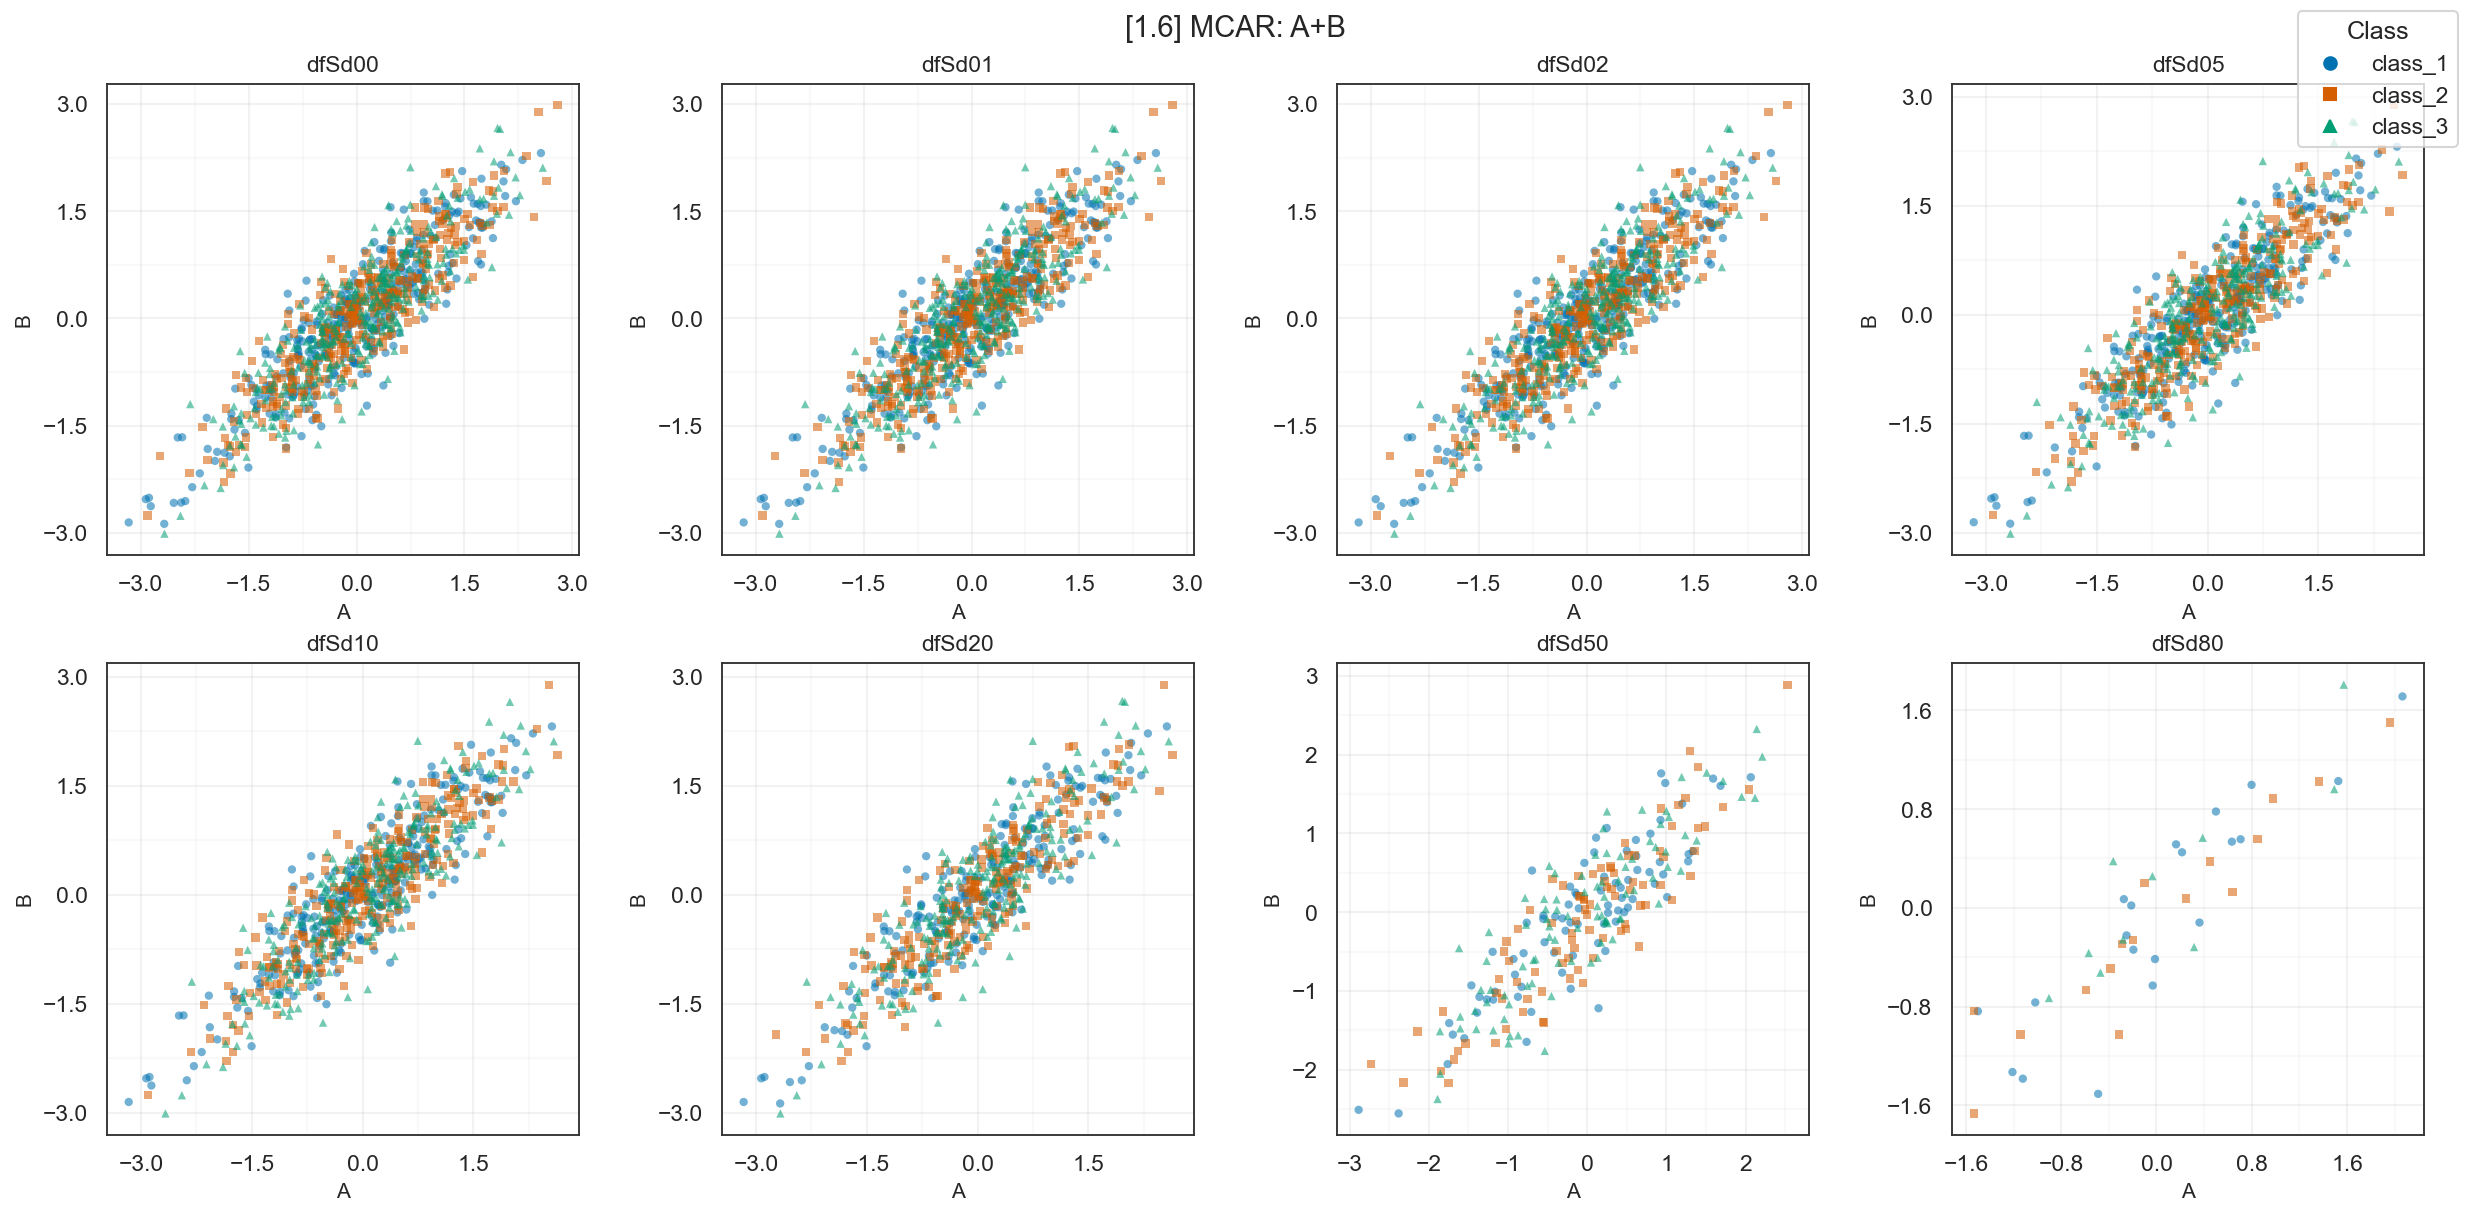

In [35]:
# [1.6]
missing_sets = {
    f"dfSd{rate:02d}": inject_mcar(dfS00, rate, seed + rate)
    for rate in MISSING_RATES
}
for name, frame in missing_sets.items():
    frame.to_csv(output_dir / "data" / f"{name}.csv", index=False)
save_missingness_summary(
    missing_sets, output_dir / "tables" / "1_6_mcar_missingness.csv"
)
display(pd.read_csv(output_dir / "tables" / "1_6_mcar_missingness.csv"))
plot_scatter_panel(
    missing_sets,
    pair1,
    output_dir / "figures" / "1_6_mcar_scatter_panel.png",
    style,
    f"[1.6] MCAR: {pair1[0]}+{pair1[1]}",
)


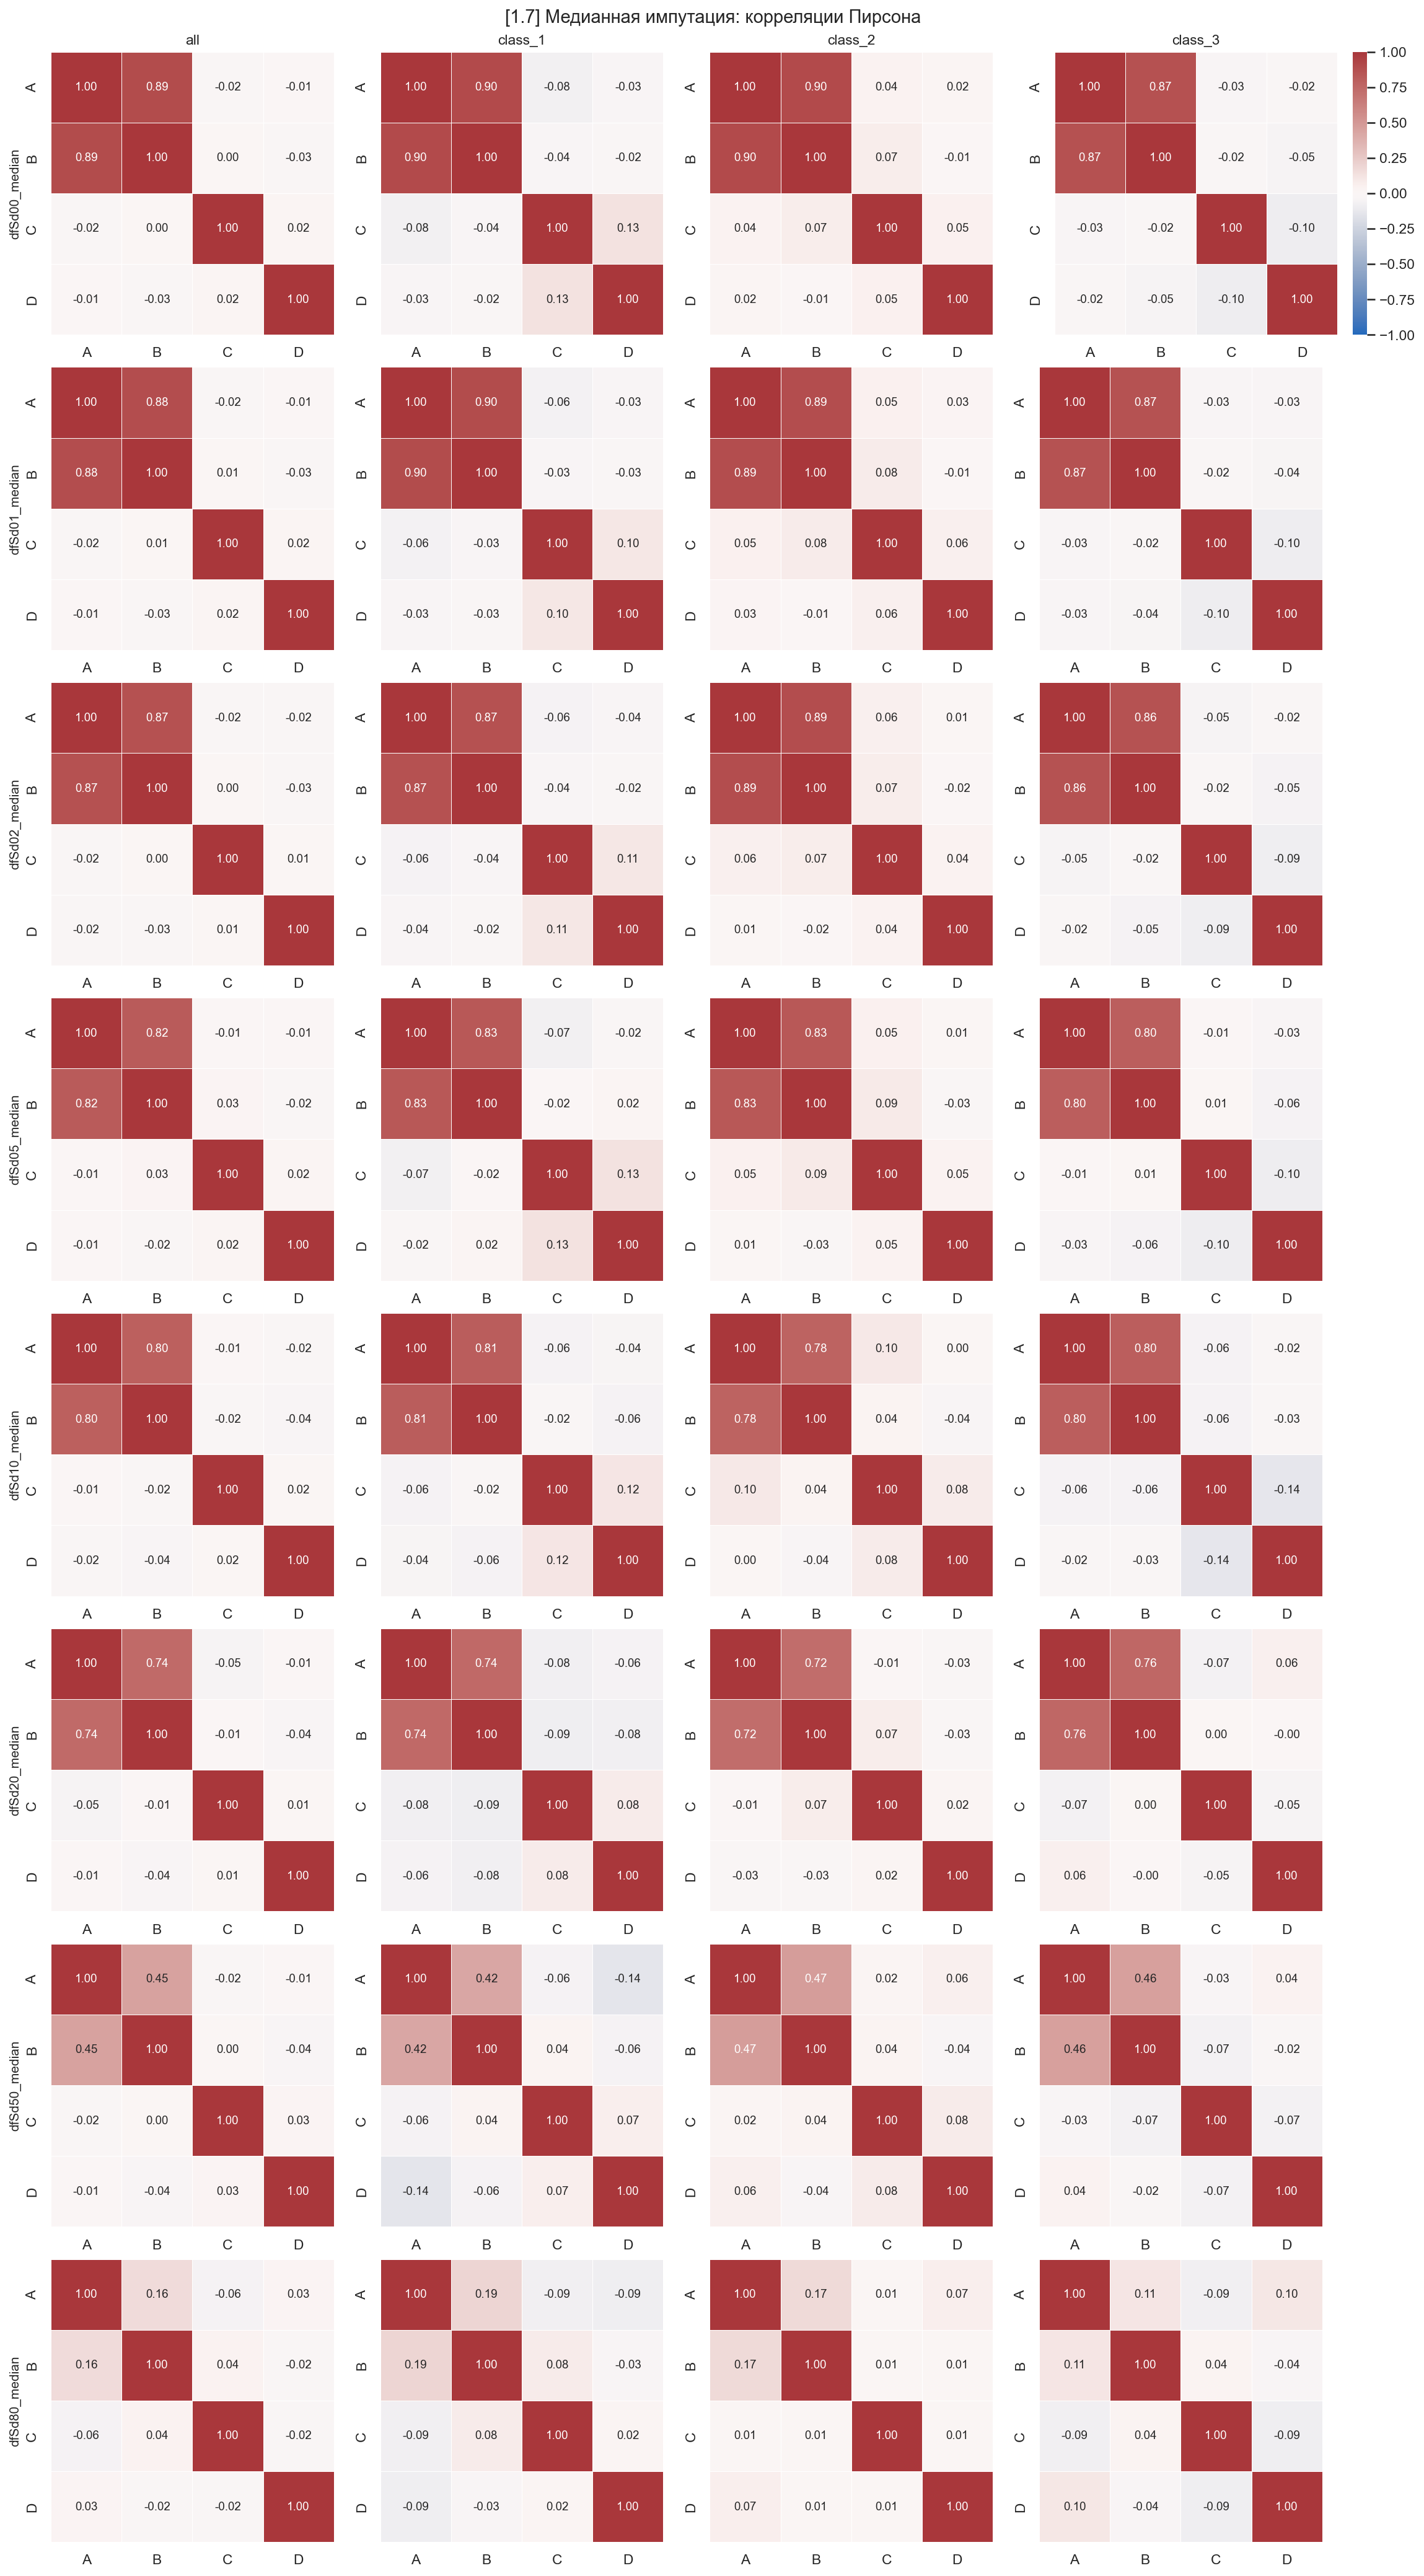

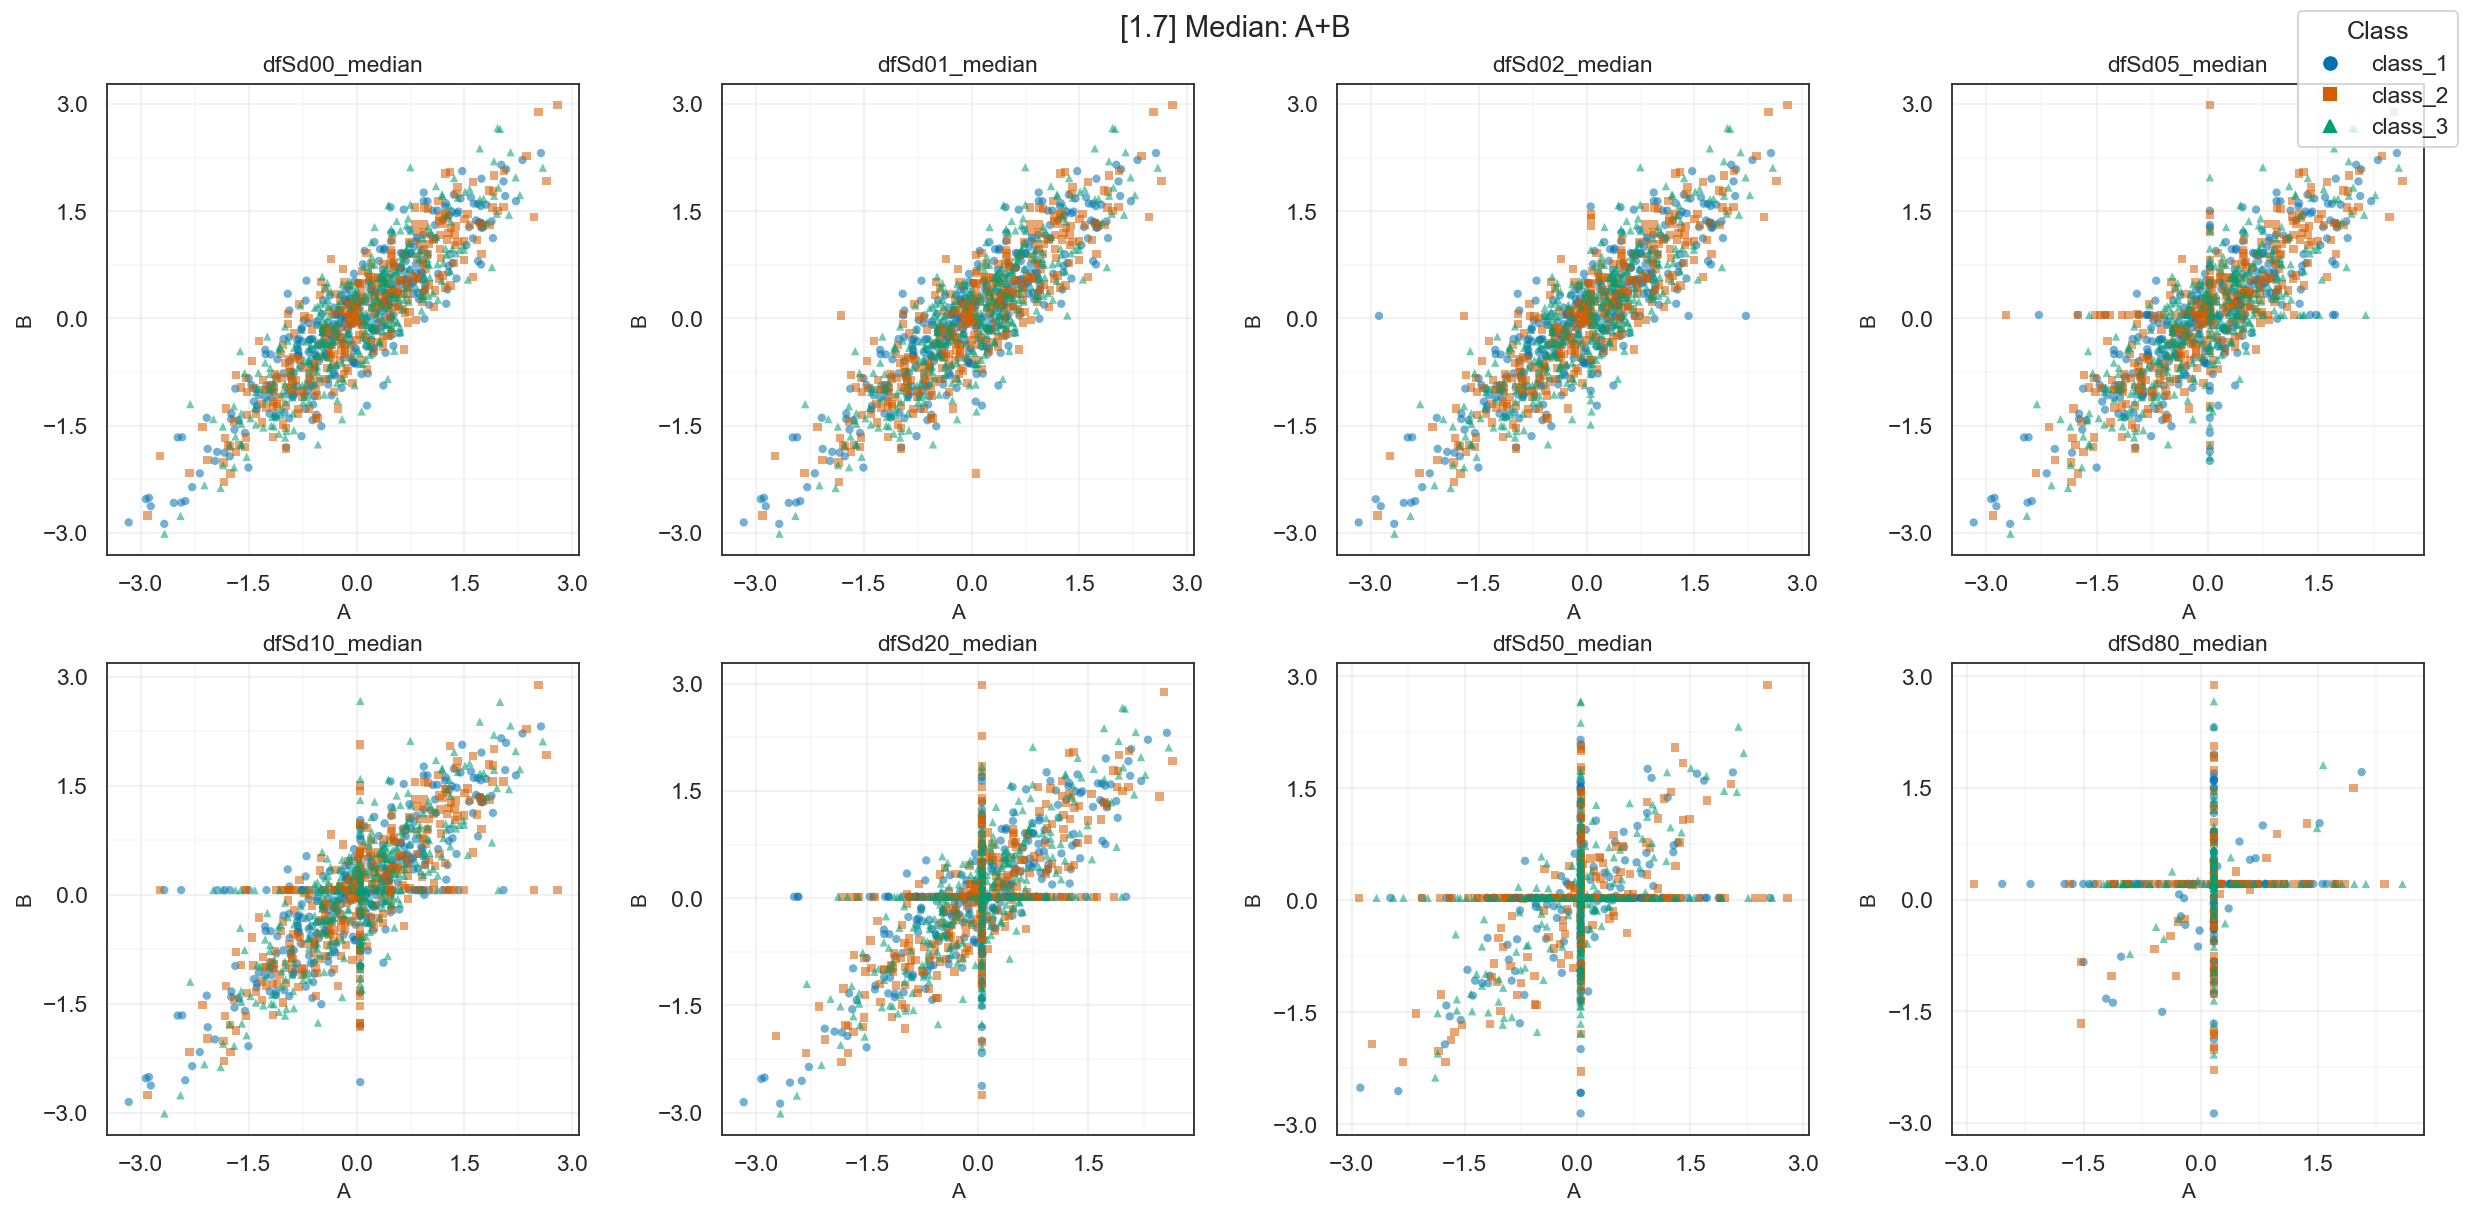

In [36]:
# [1.7]
median_sets = {
    f"{name}_median": impute_dataset(frame, "median", seed)
    for name, frame in missing_sets.items()
}
for name, frame in median_sets.items():
    frame.to_csv(output_dir / "data" / f"{name}.csv", index=False)
plot_correlation_comparison(
    median_sets,
    output_dir / "figures" / "1_7_median_correlations.png",
    style,
    title="[1.7] Медианная импутация: корреляции Пирсона",
)
plot_scatter_panel(
    median_sets,
    pair1,
    output_dir / "figures" / "1_7_median_scatter_panel.png",
    style,
    f"[1.7] Median: {pair1[0]}+{pair1[1]}",
)


c:\Users\bazdi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


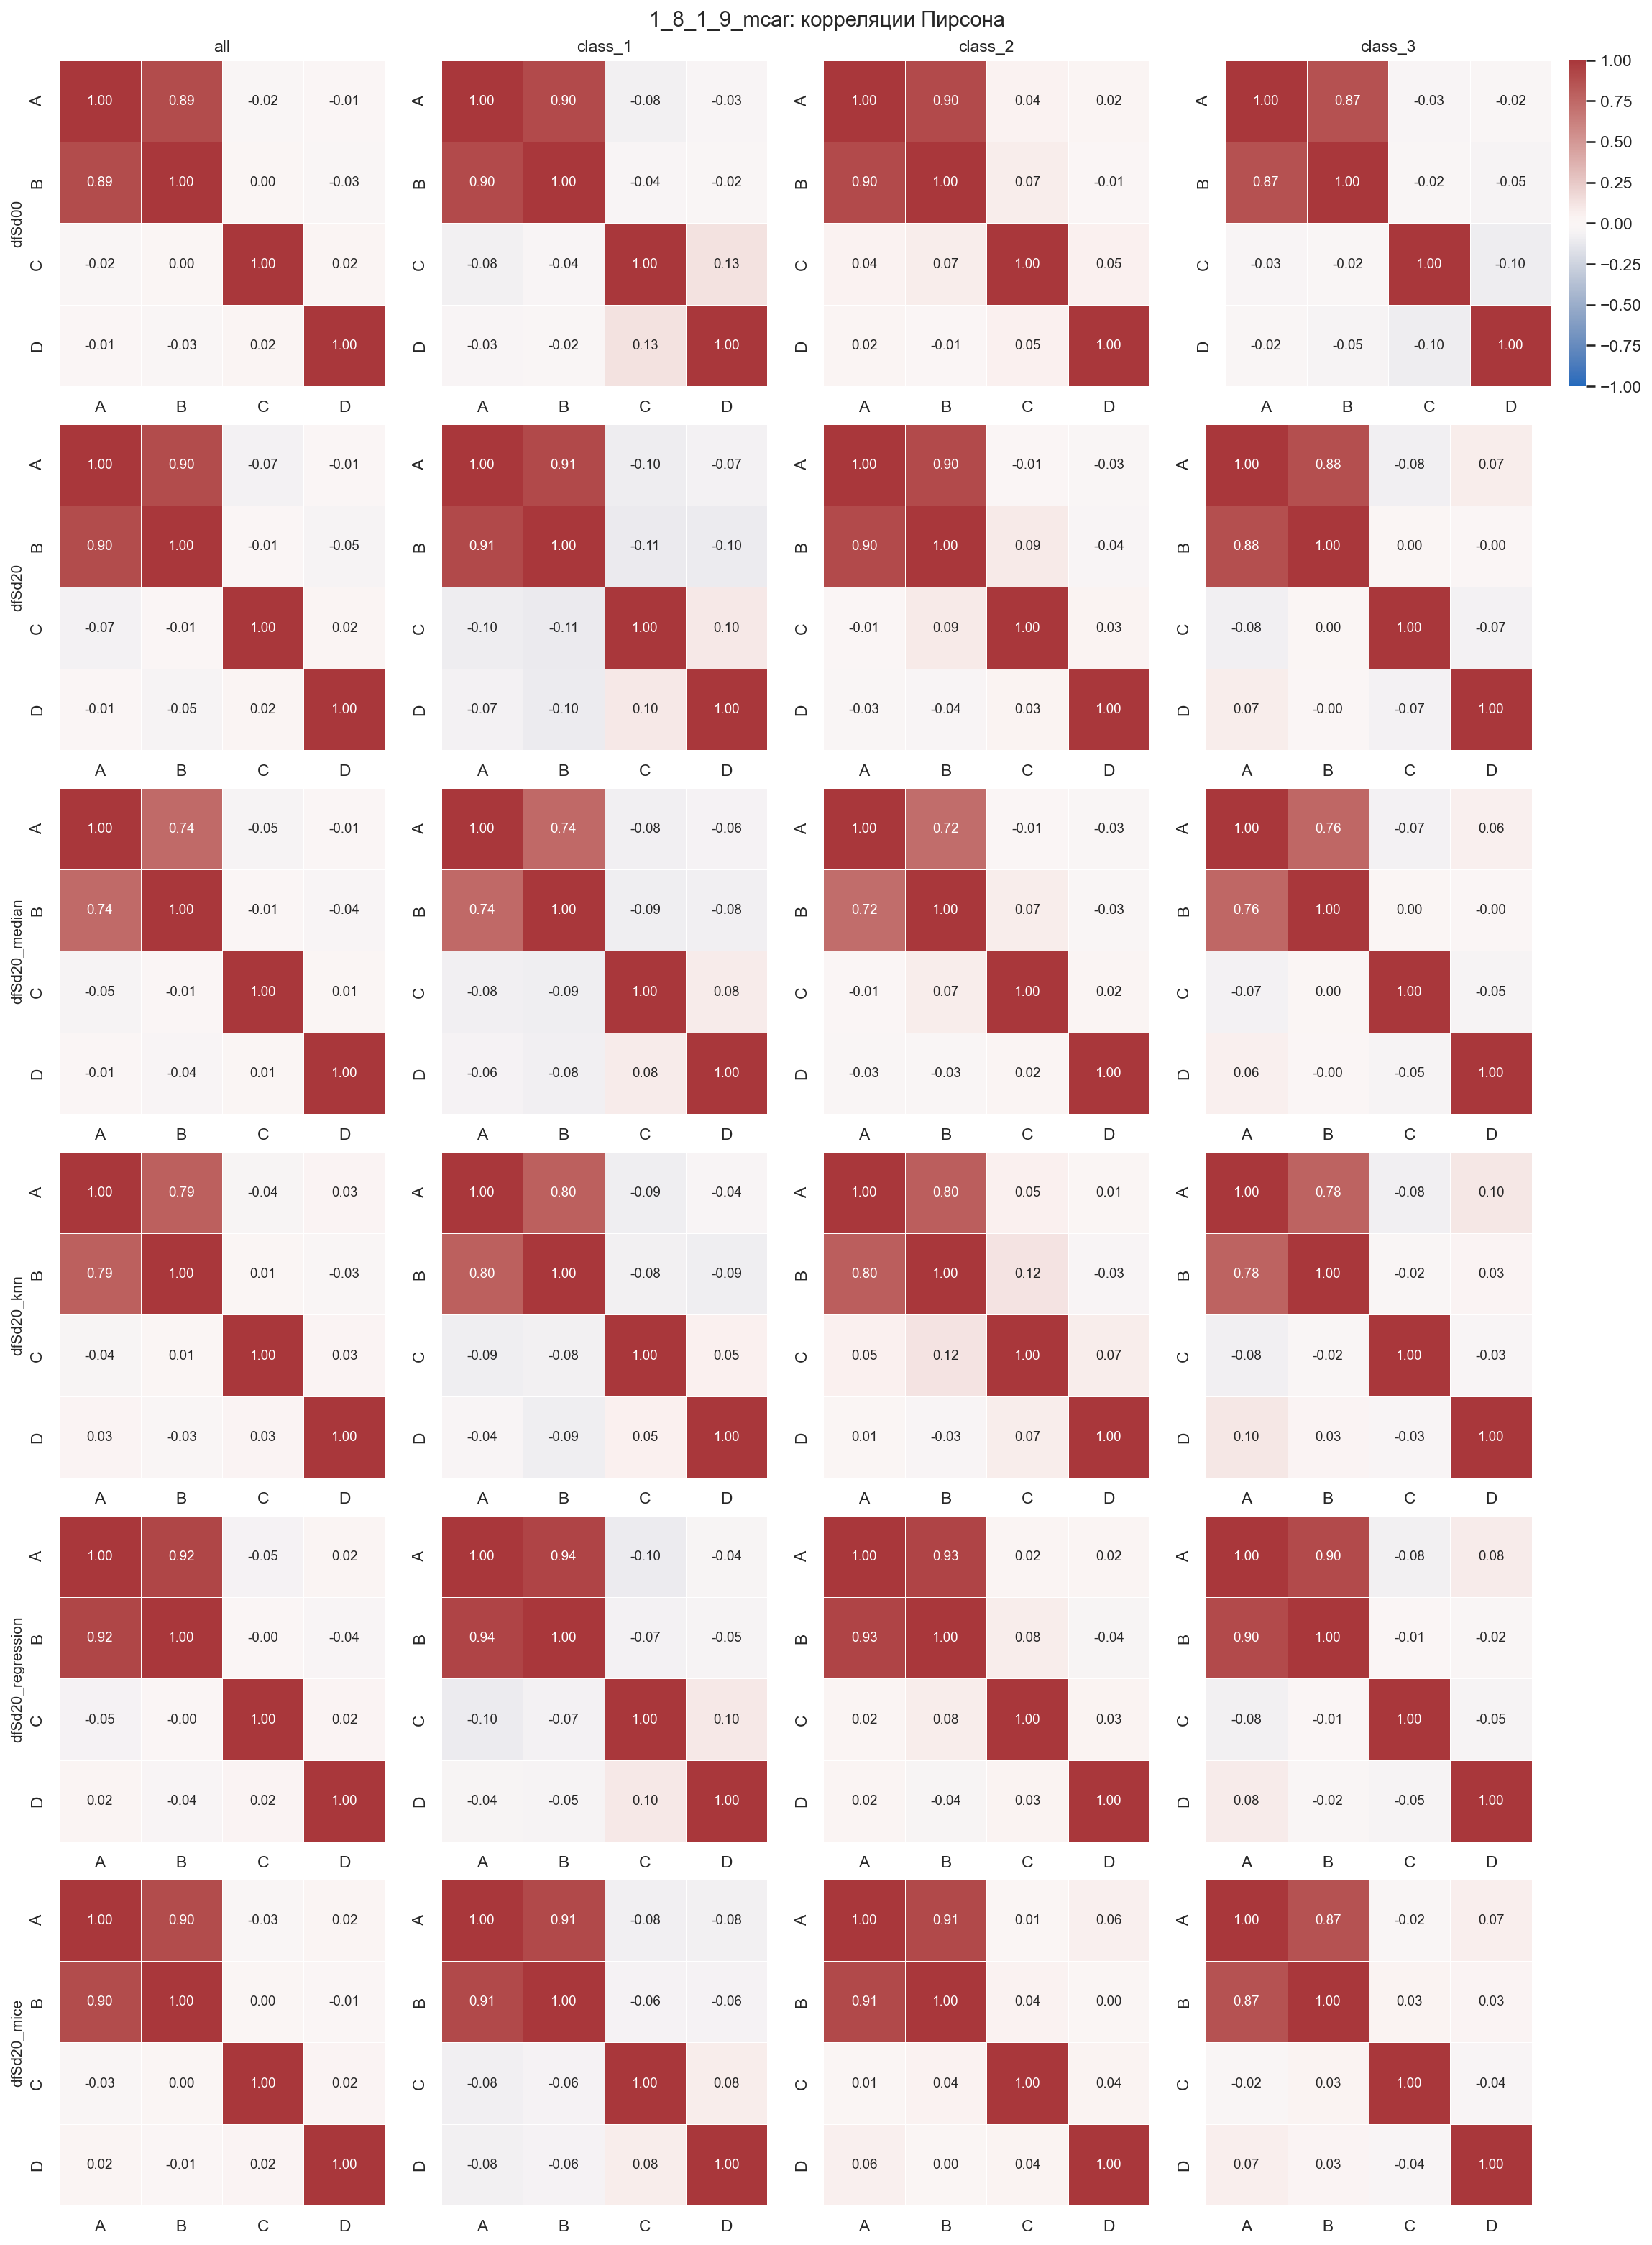

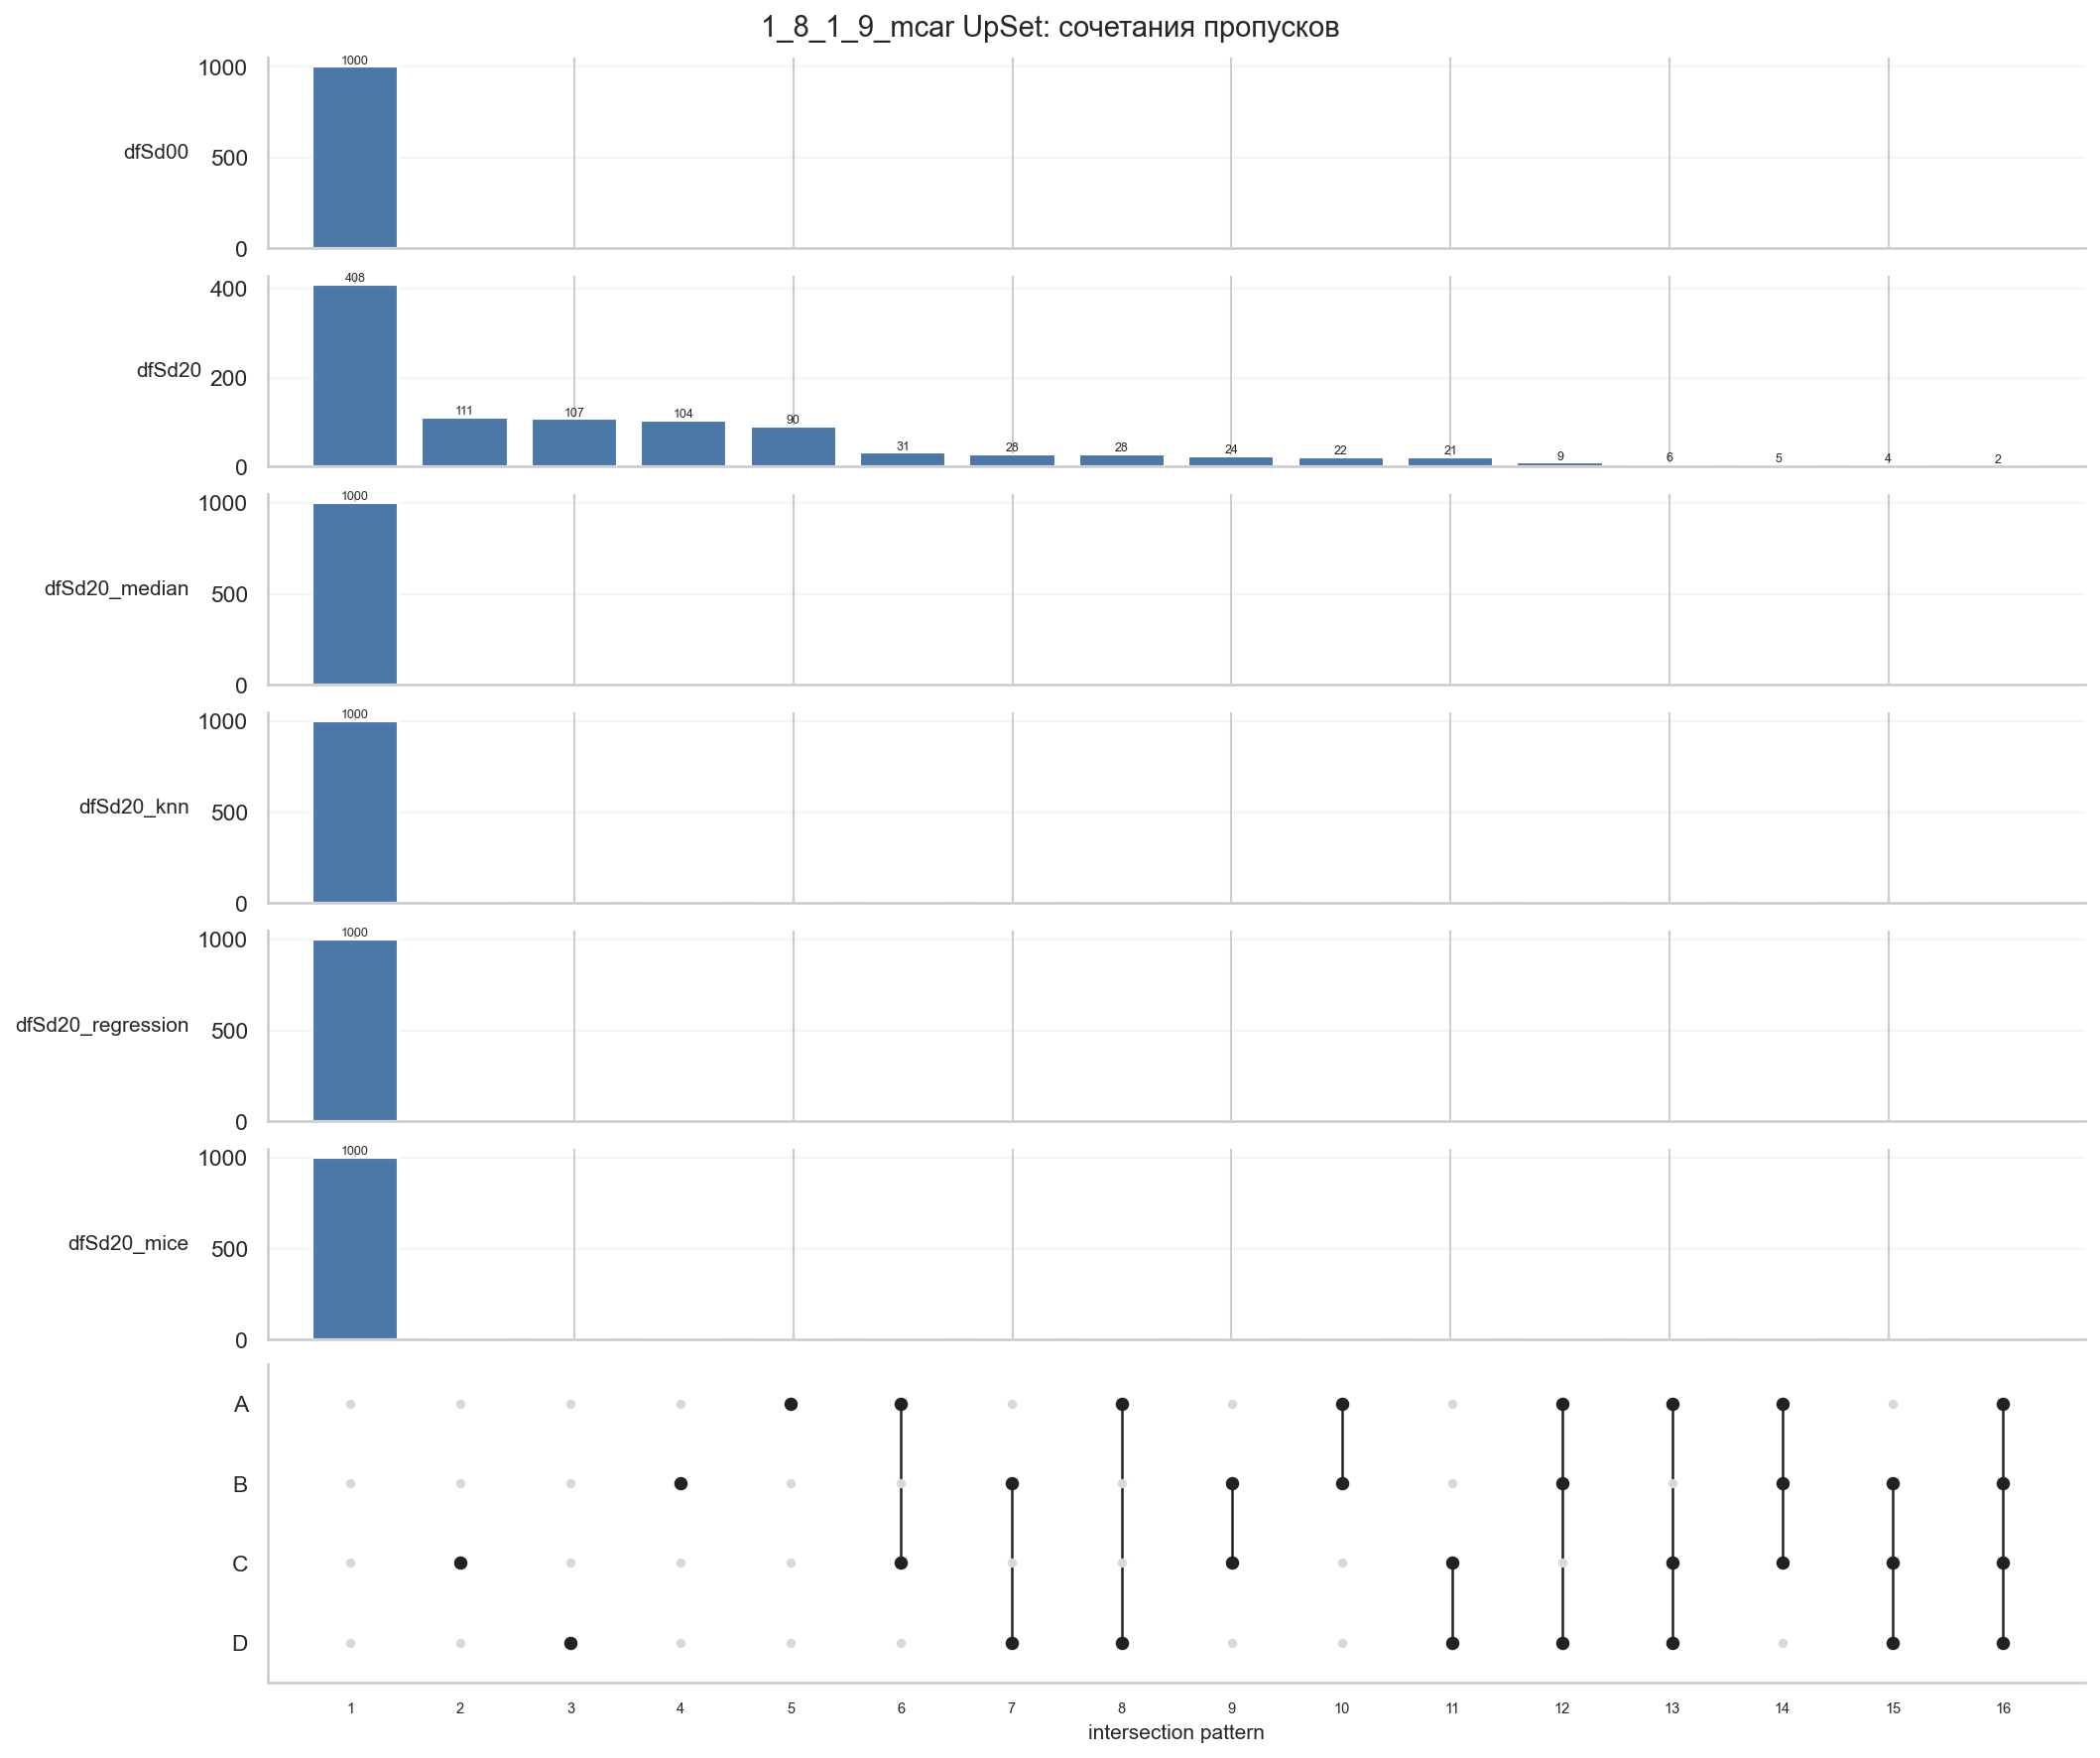

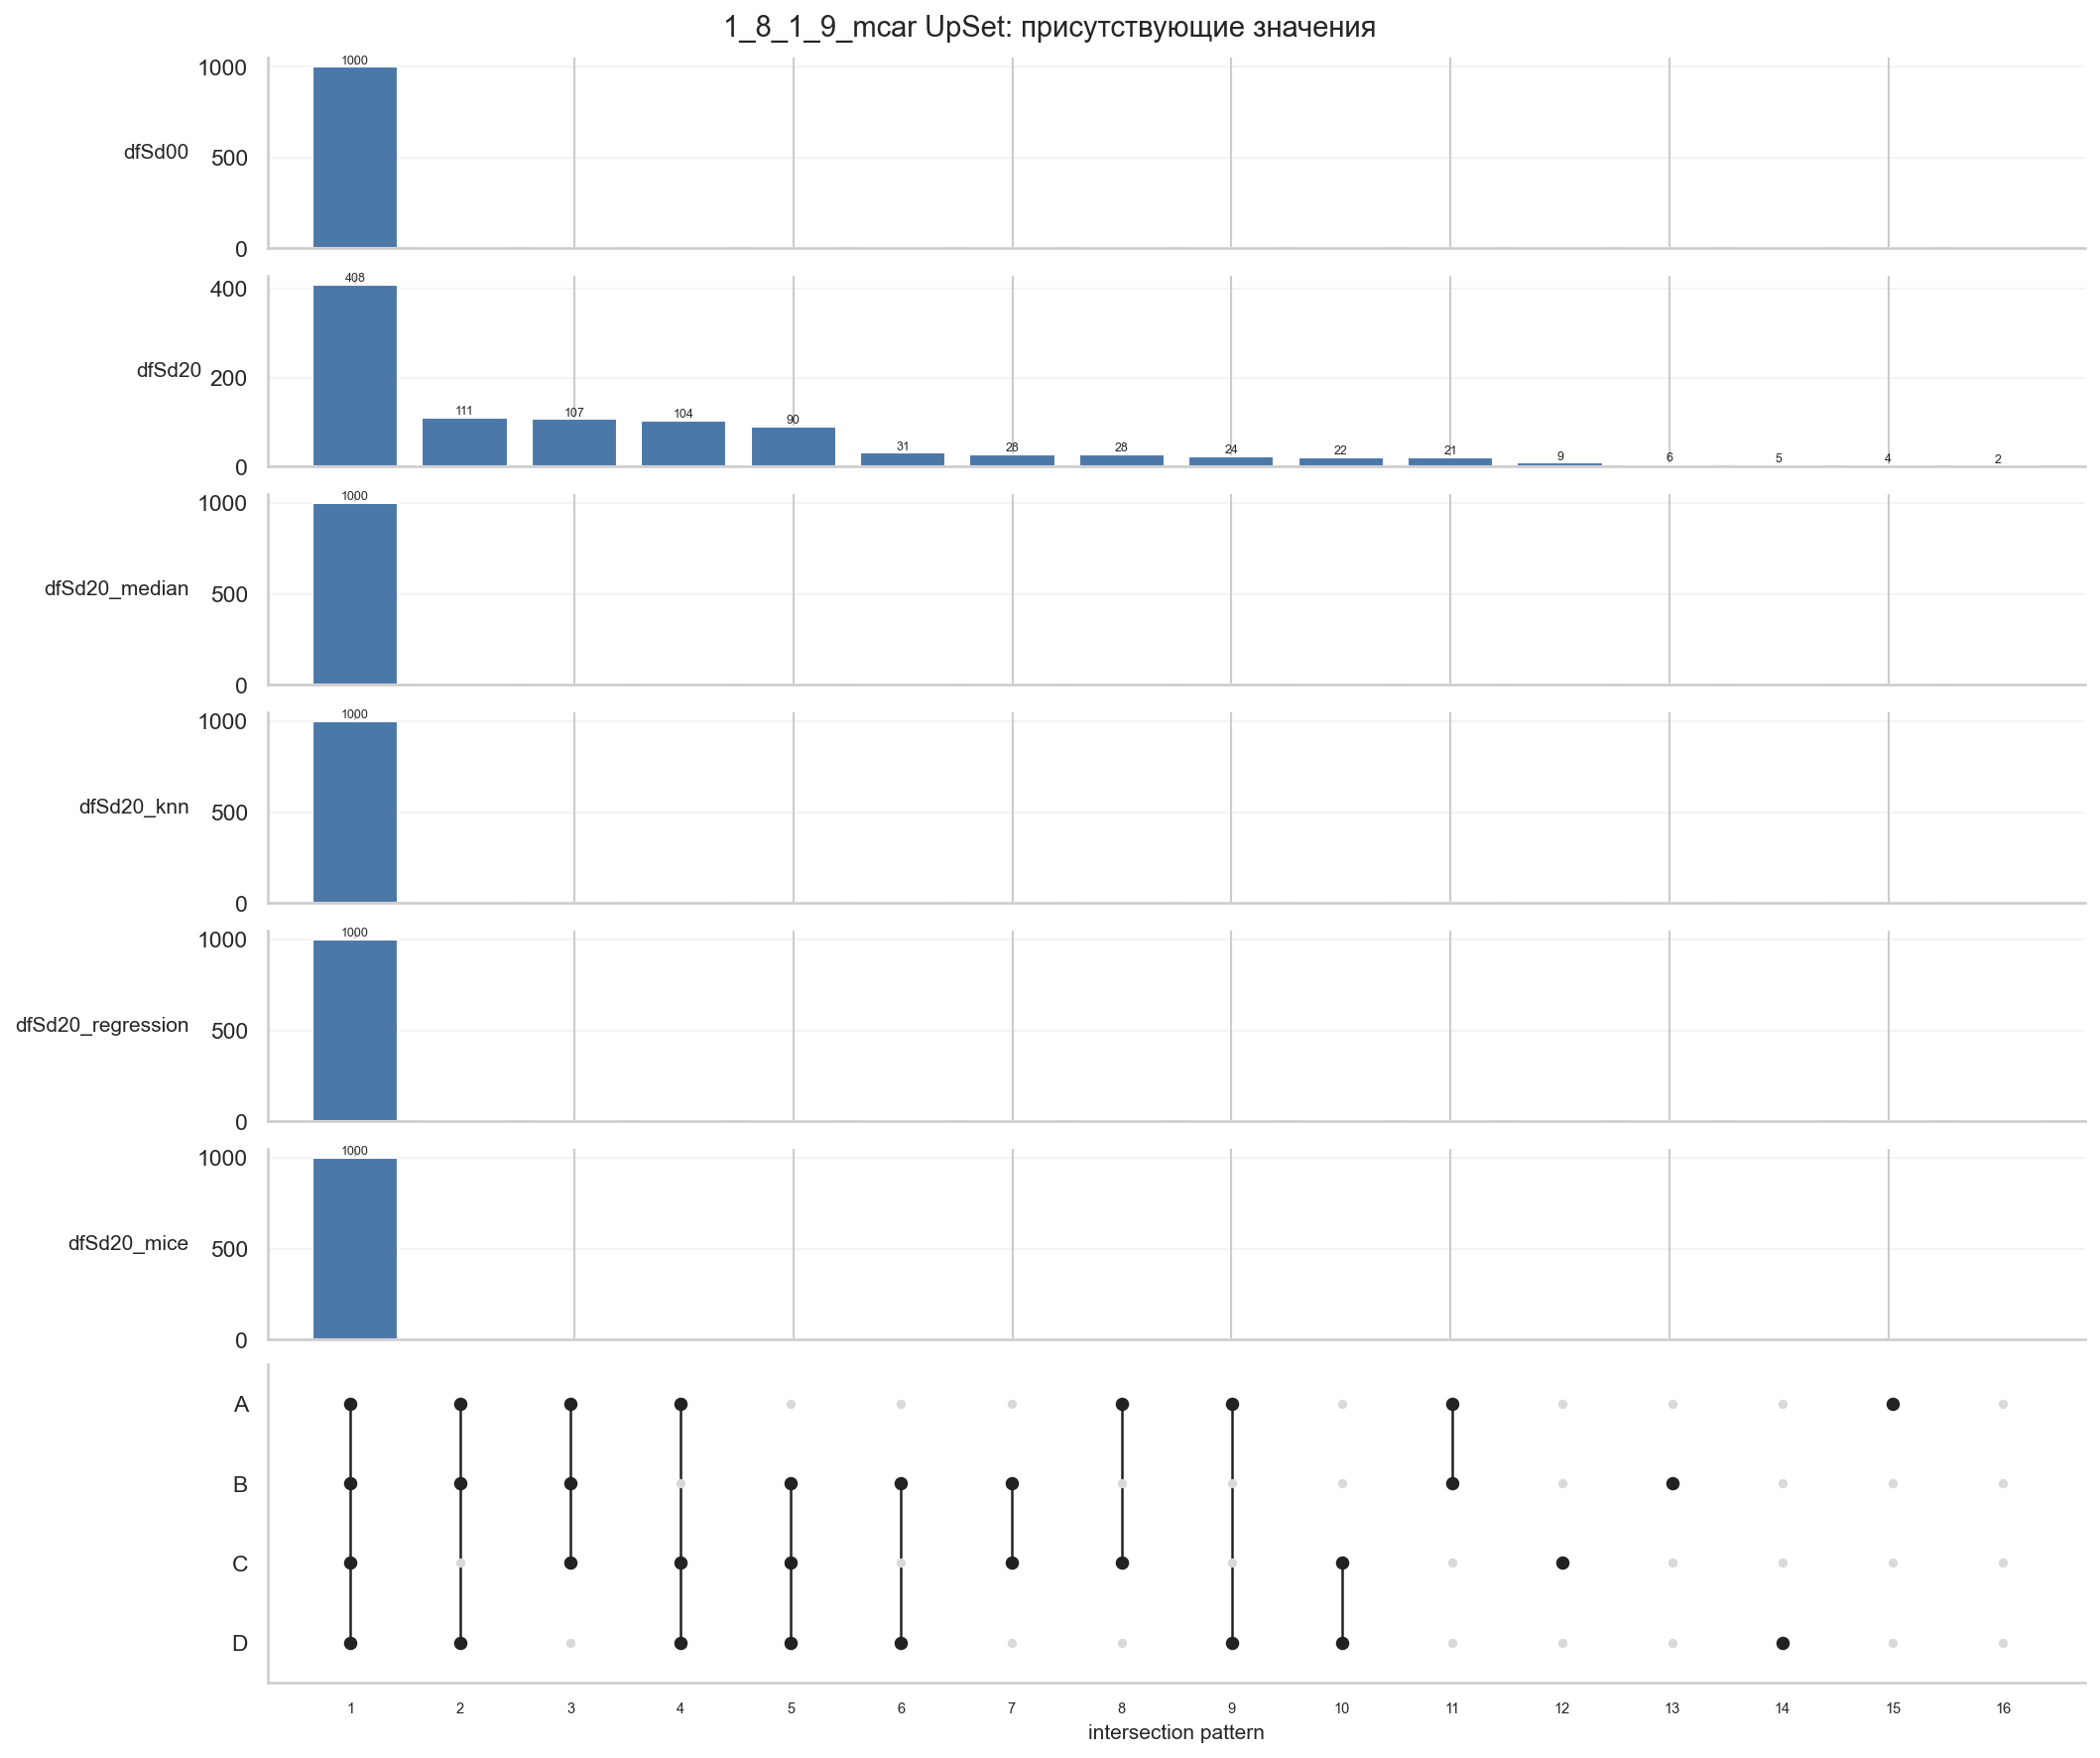

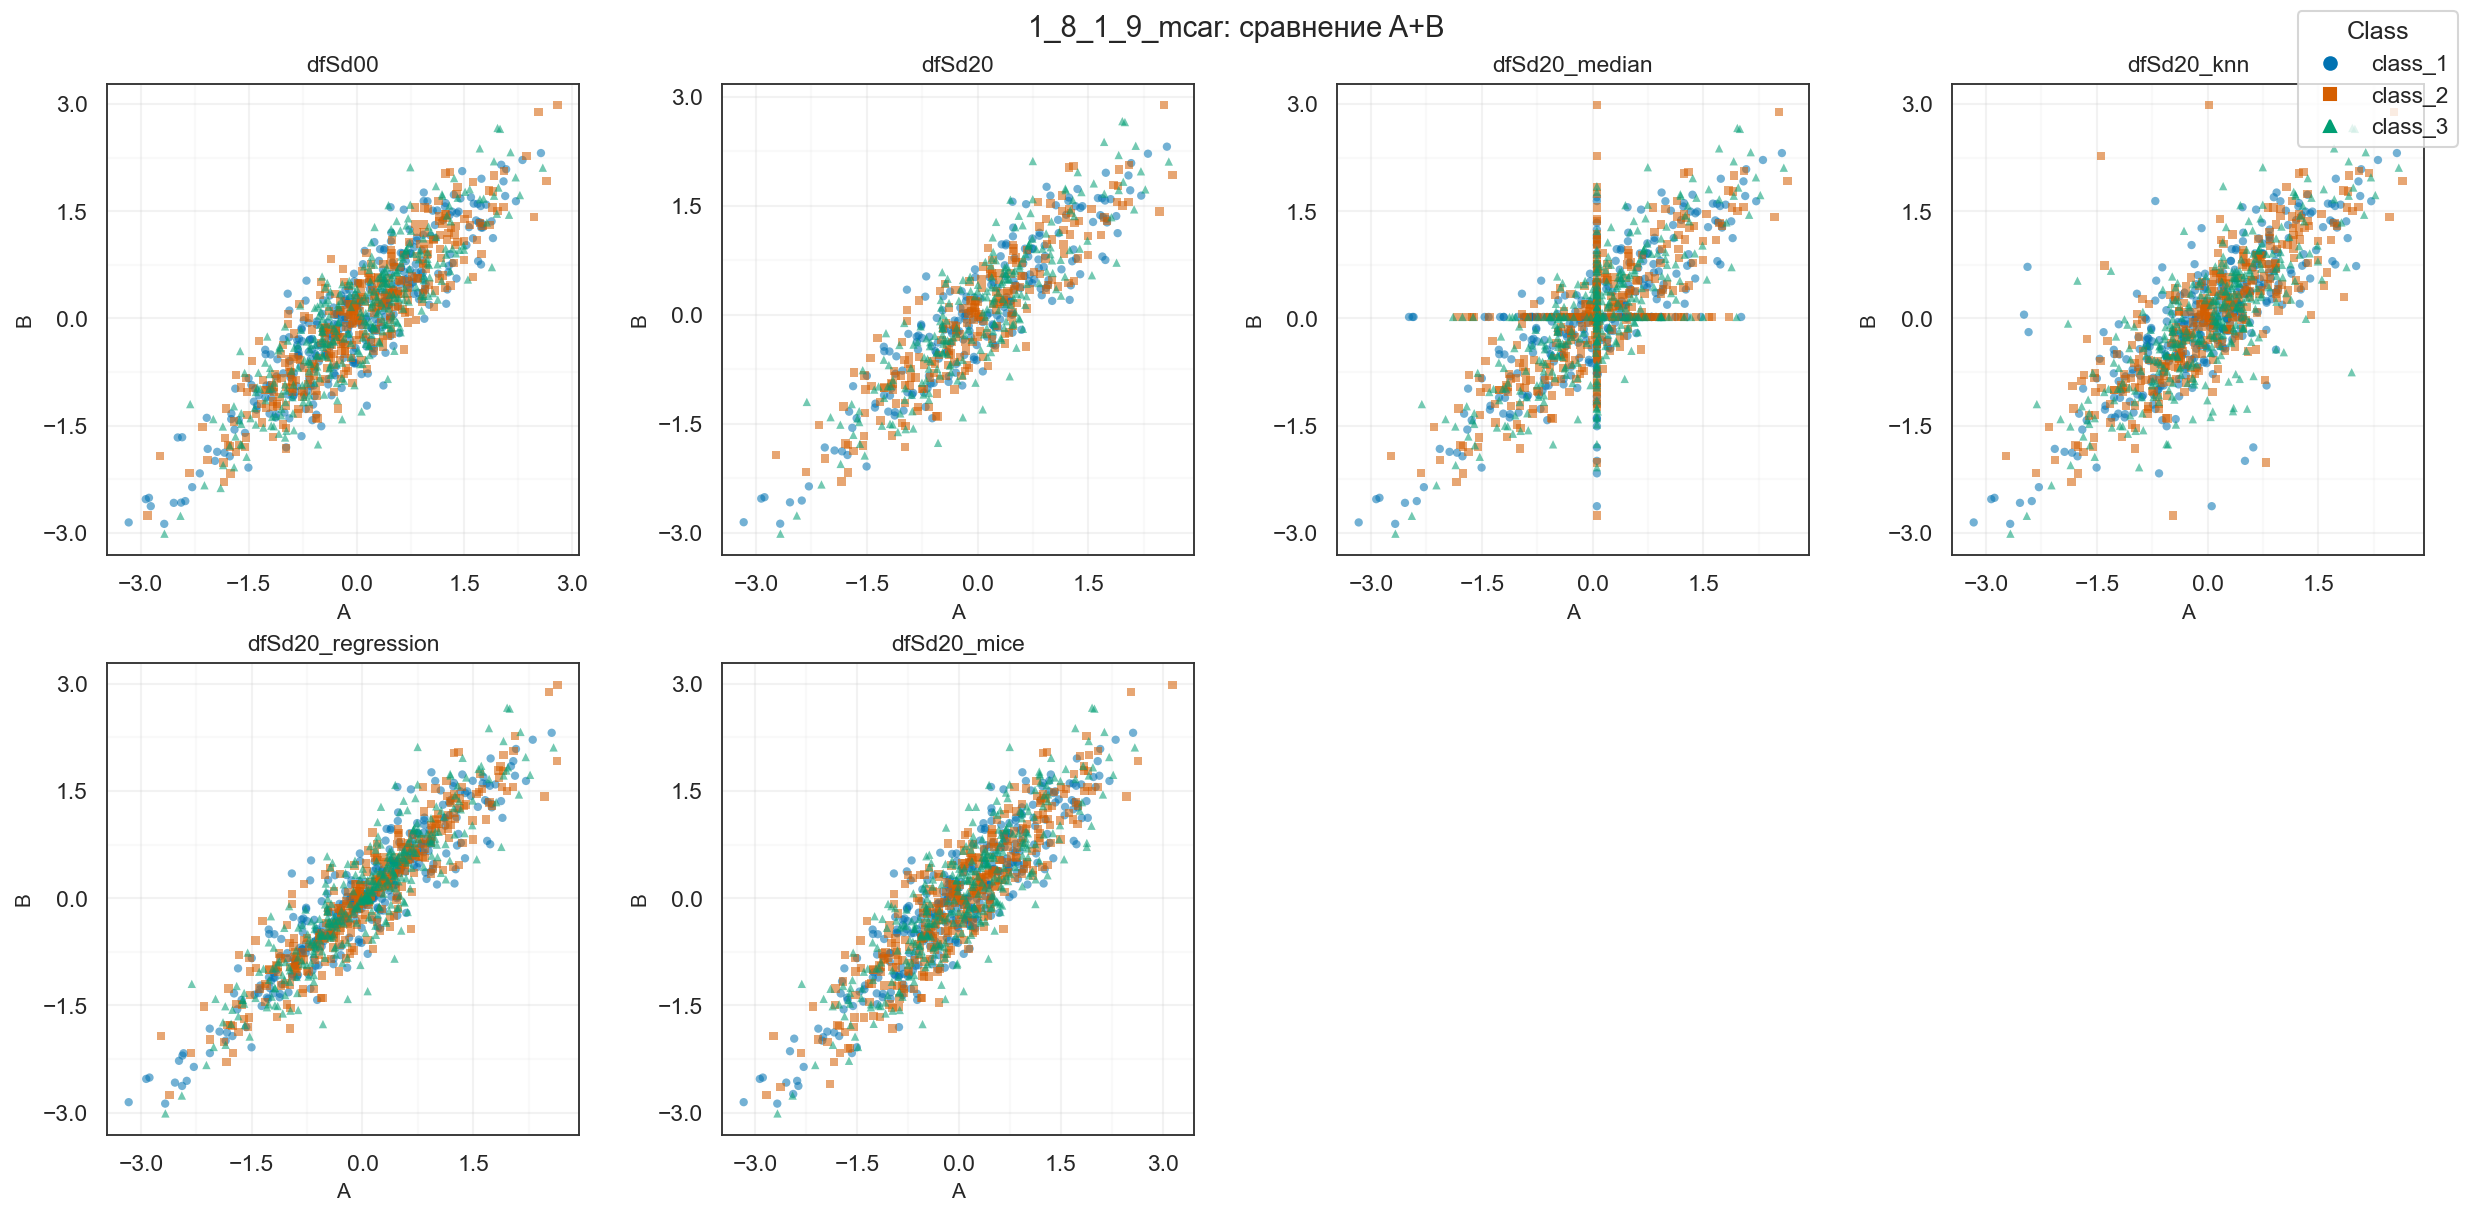

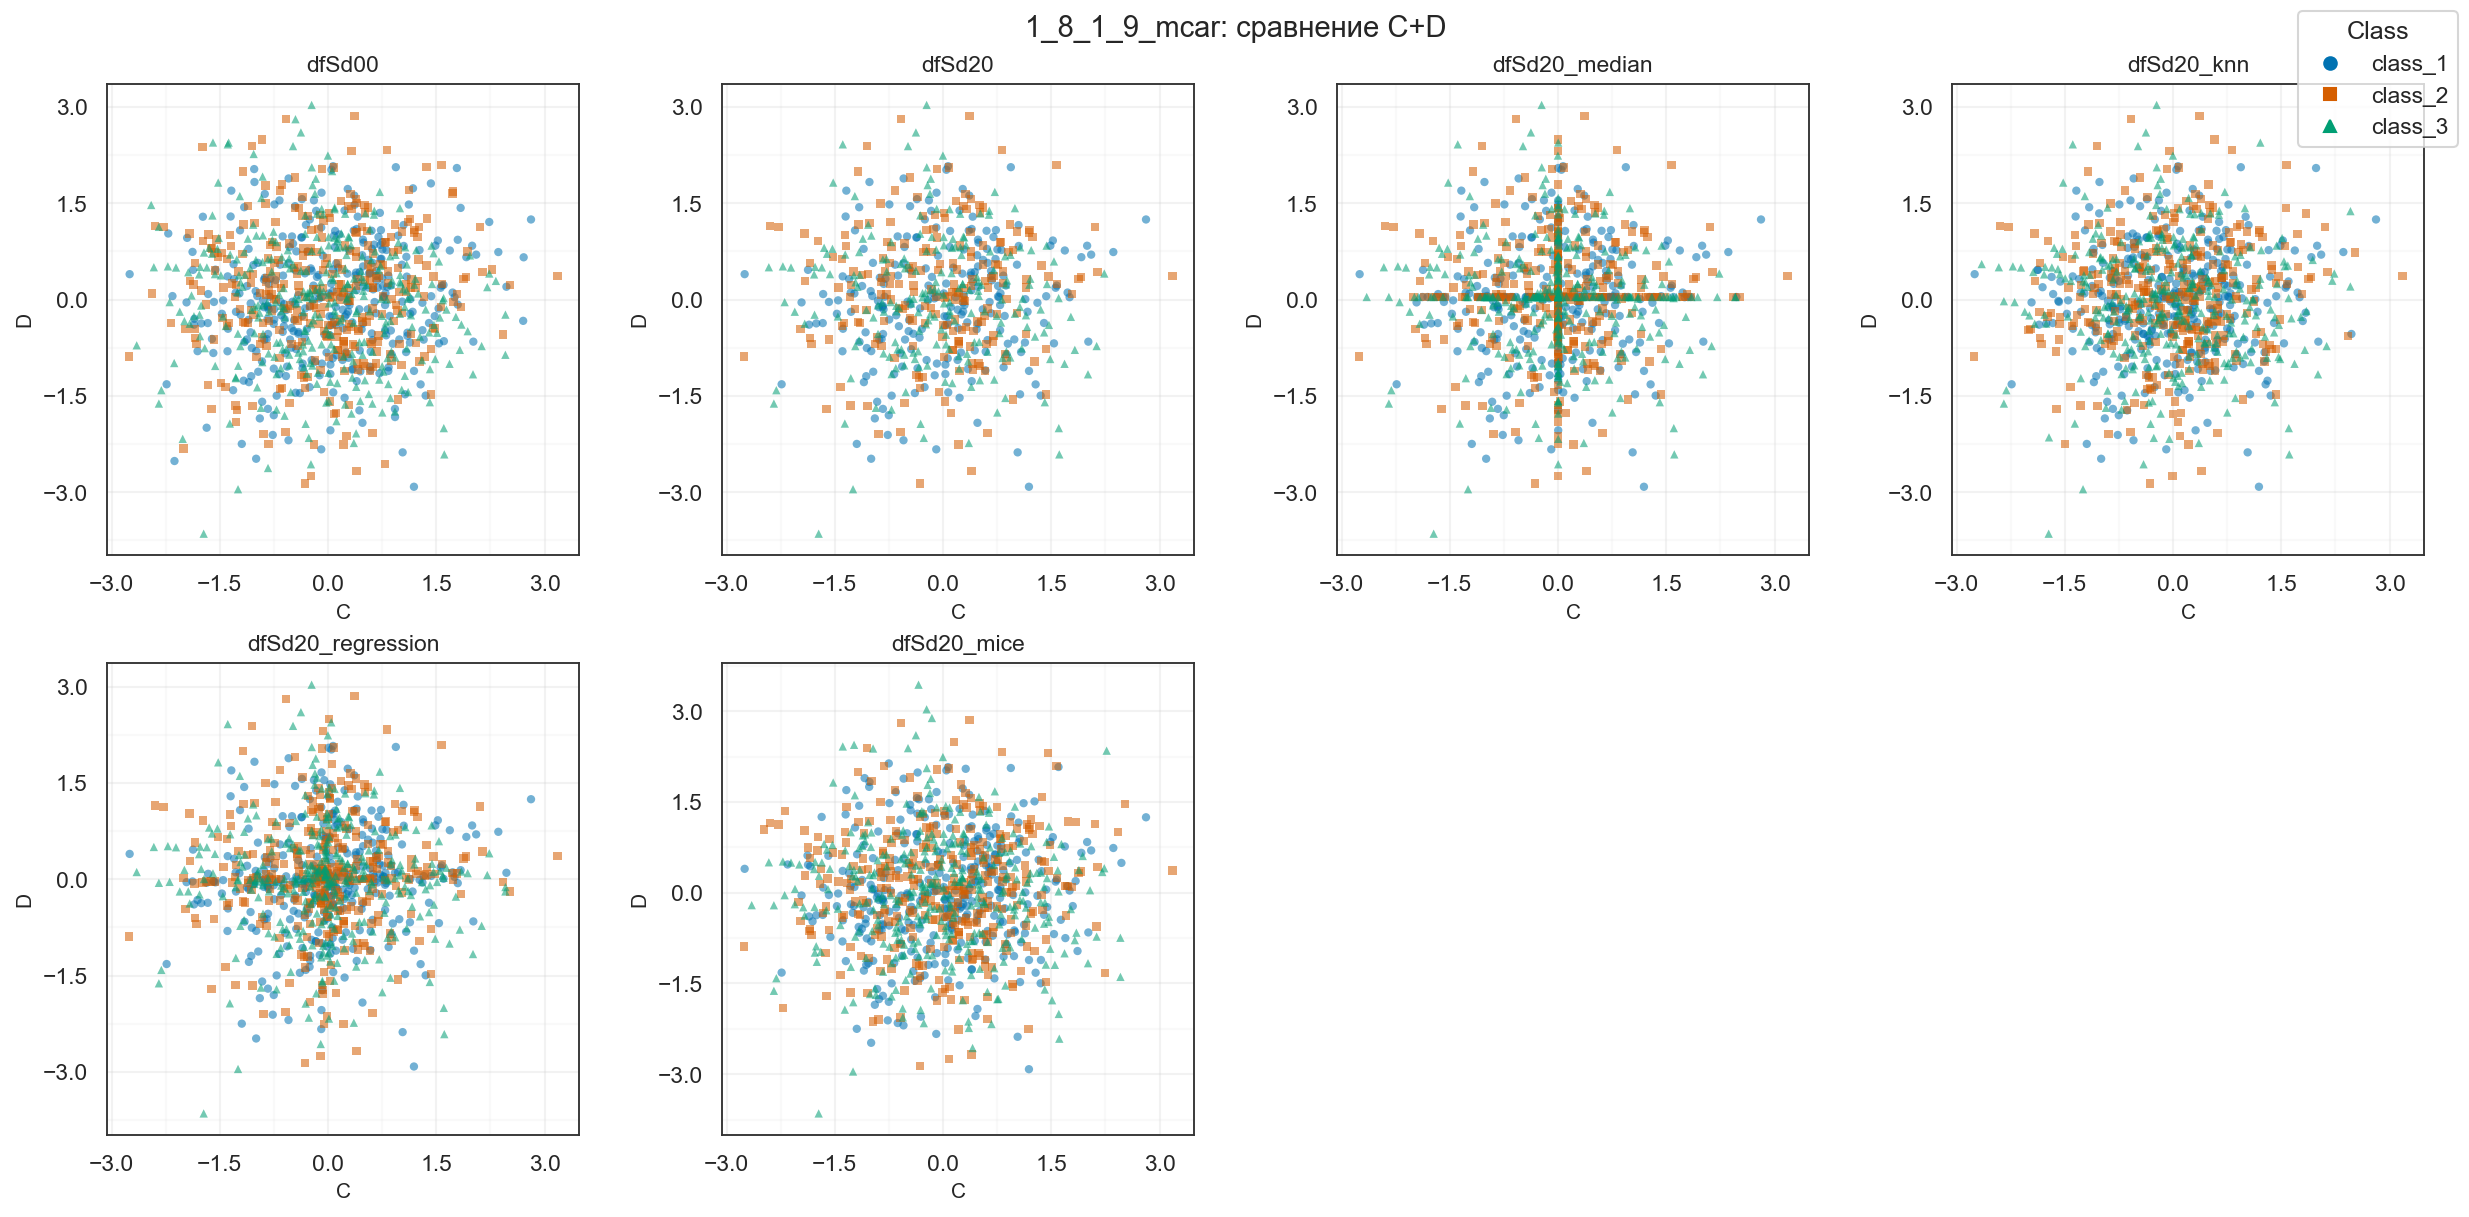

In [37]:
# [1.8]--[1.9]
selected_name = f"dfSd{missing_rate:02d}"
mcar_comparison = comparison_workflow(
    base_df=dfS00,
    missing_df=missing_sets[selected_name],
    base_name="dfSd00",
    missing_name=selected_name,
    output_dir=output_dir,
    style=style,
    random_state=seed,
    knn_neighbors=knn_neighbors,
    pair1=pair1,
    pair2=pair2,
    task_prefix="1_8_1_9_mcar",
)


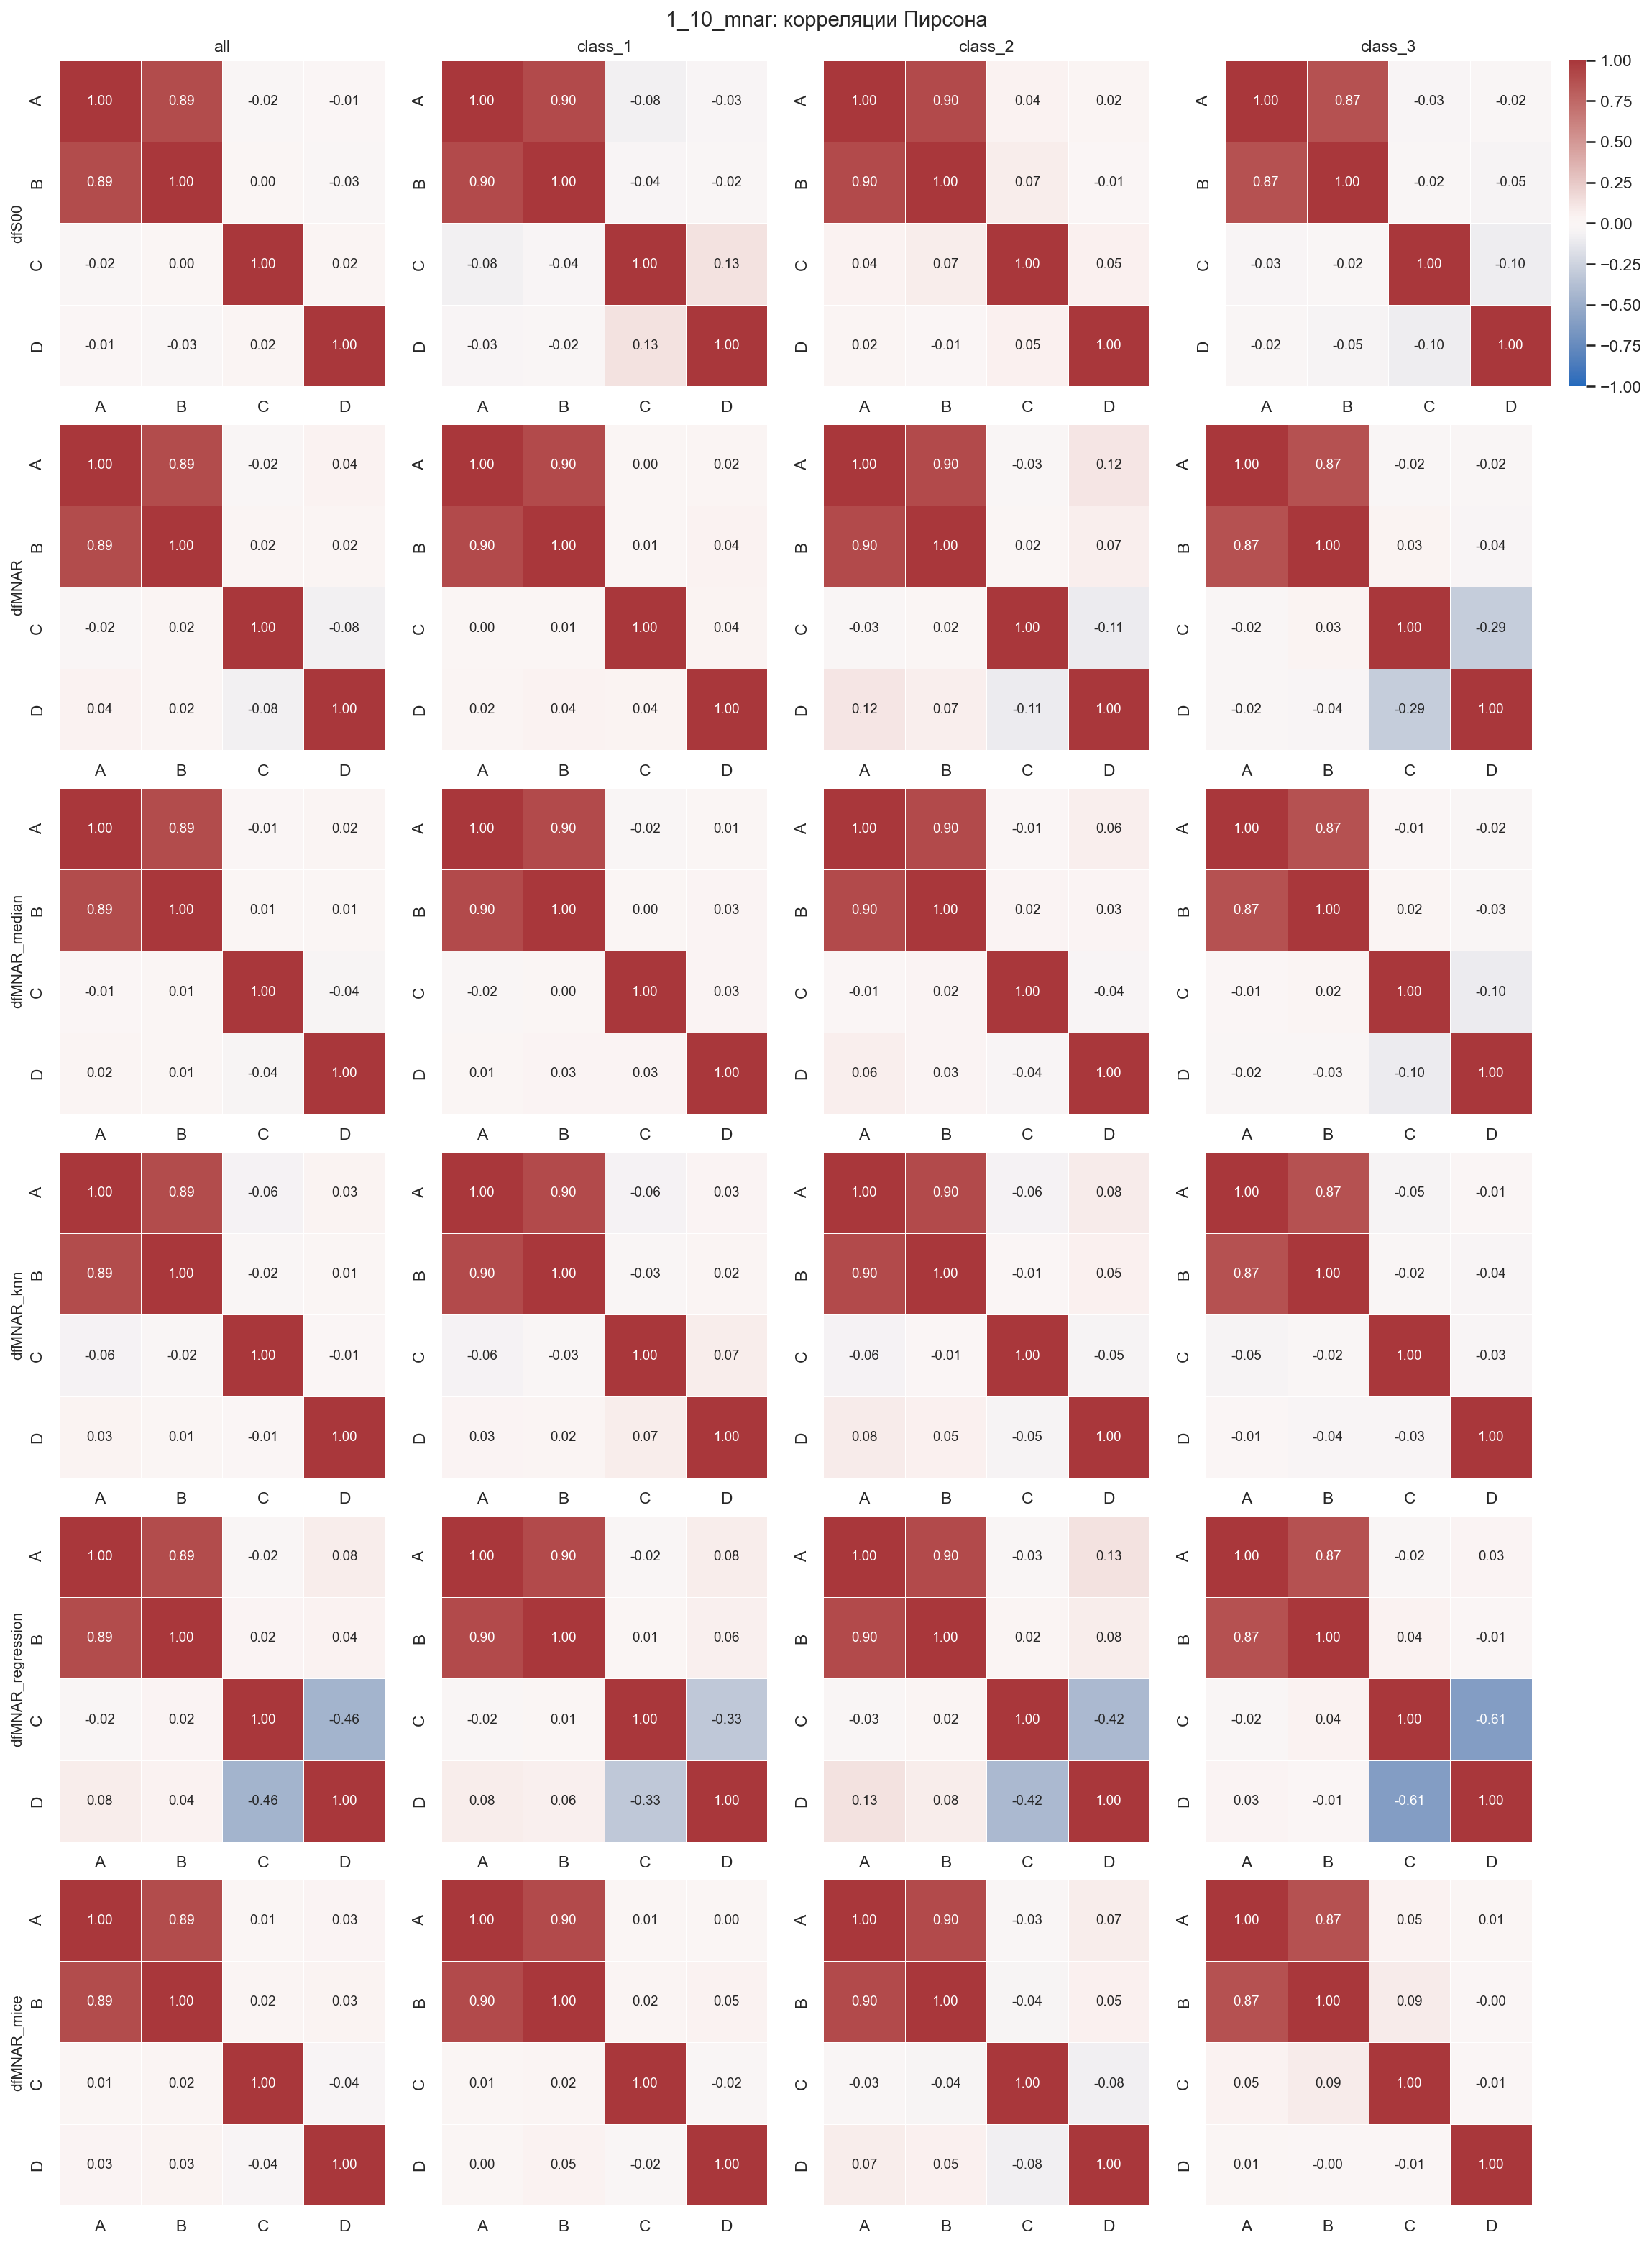

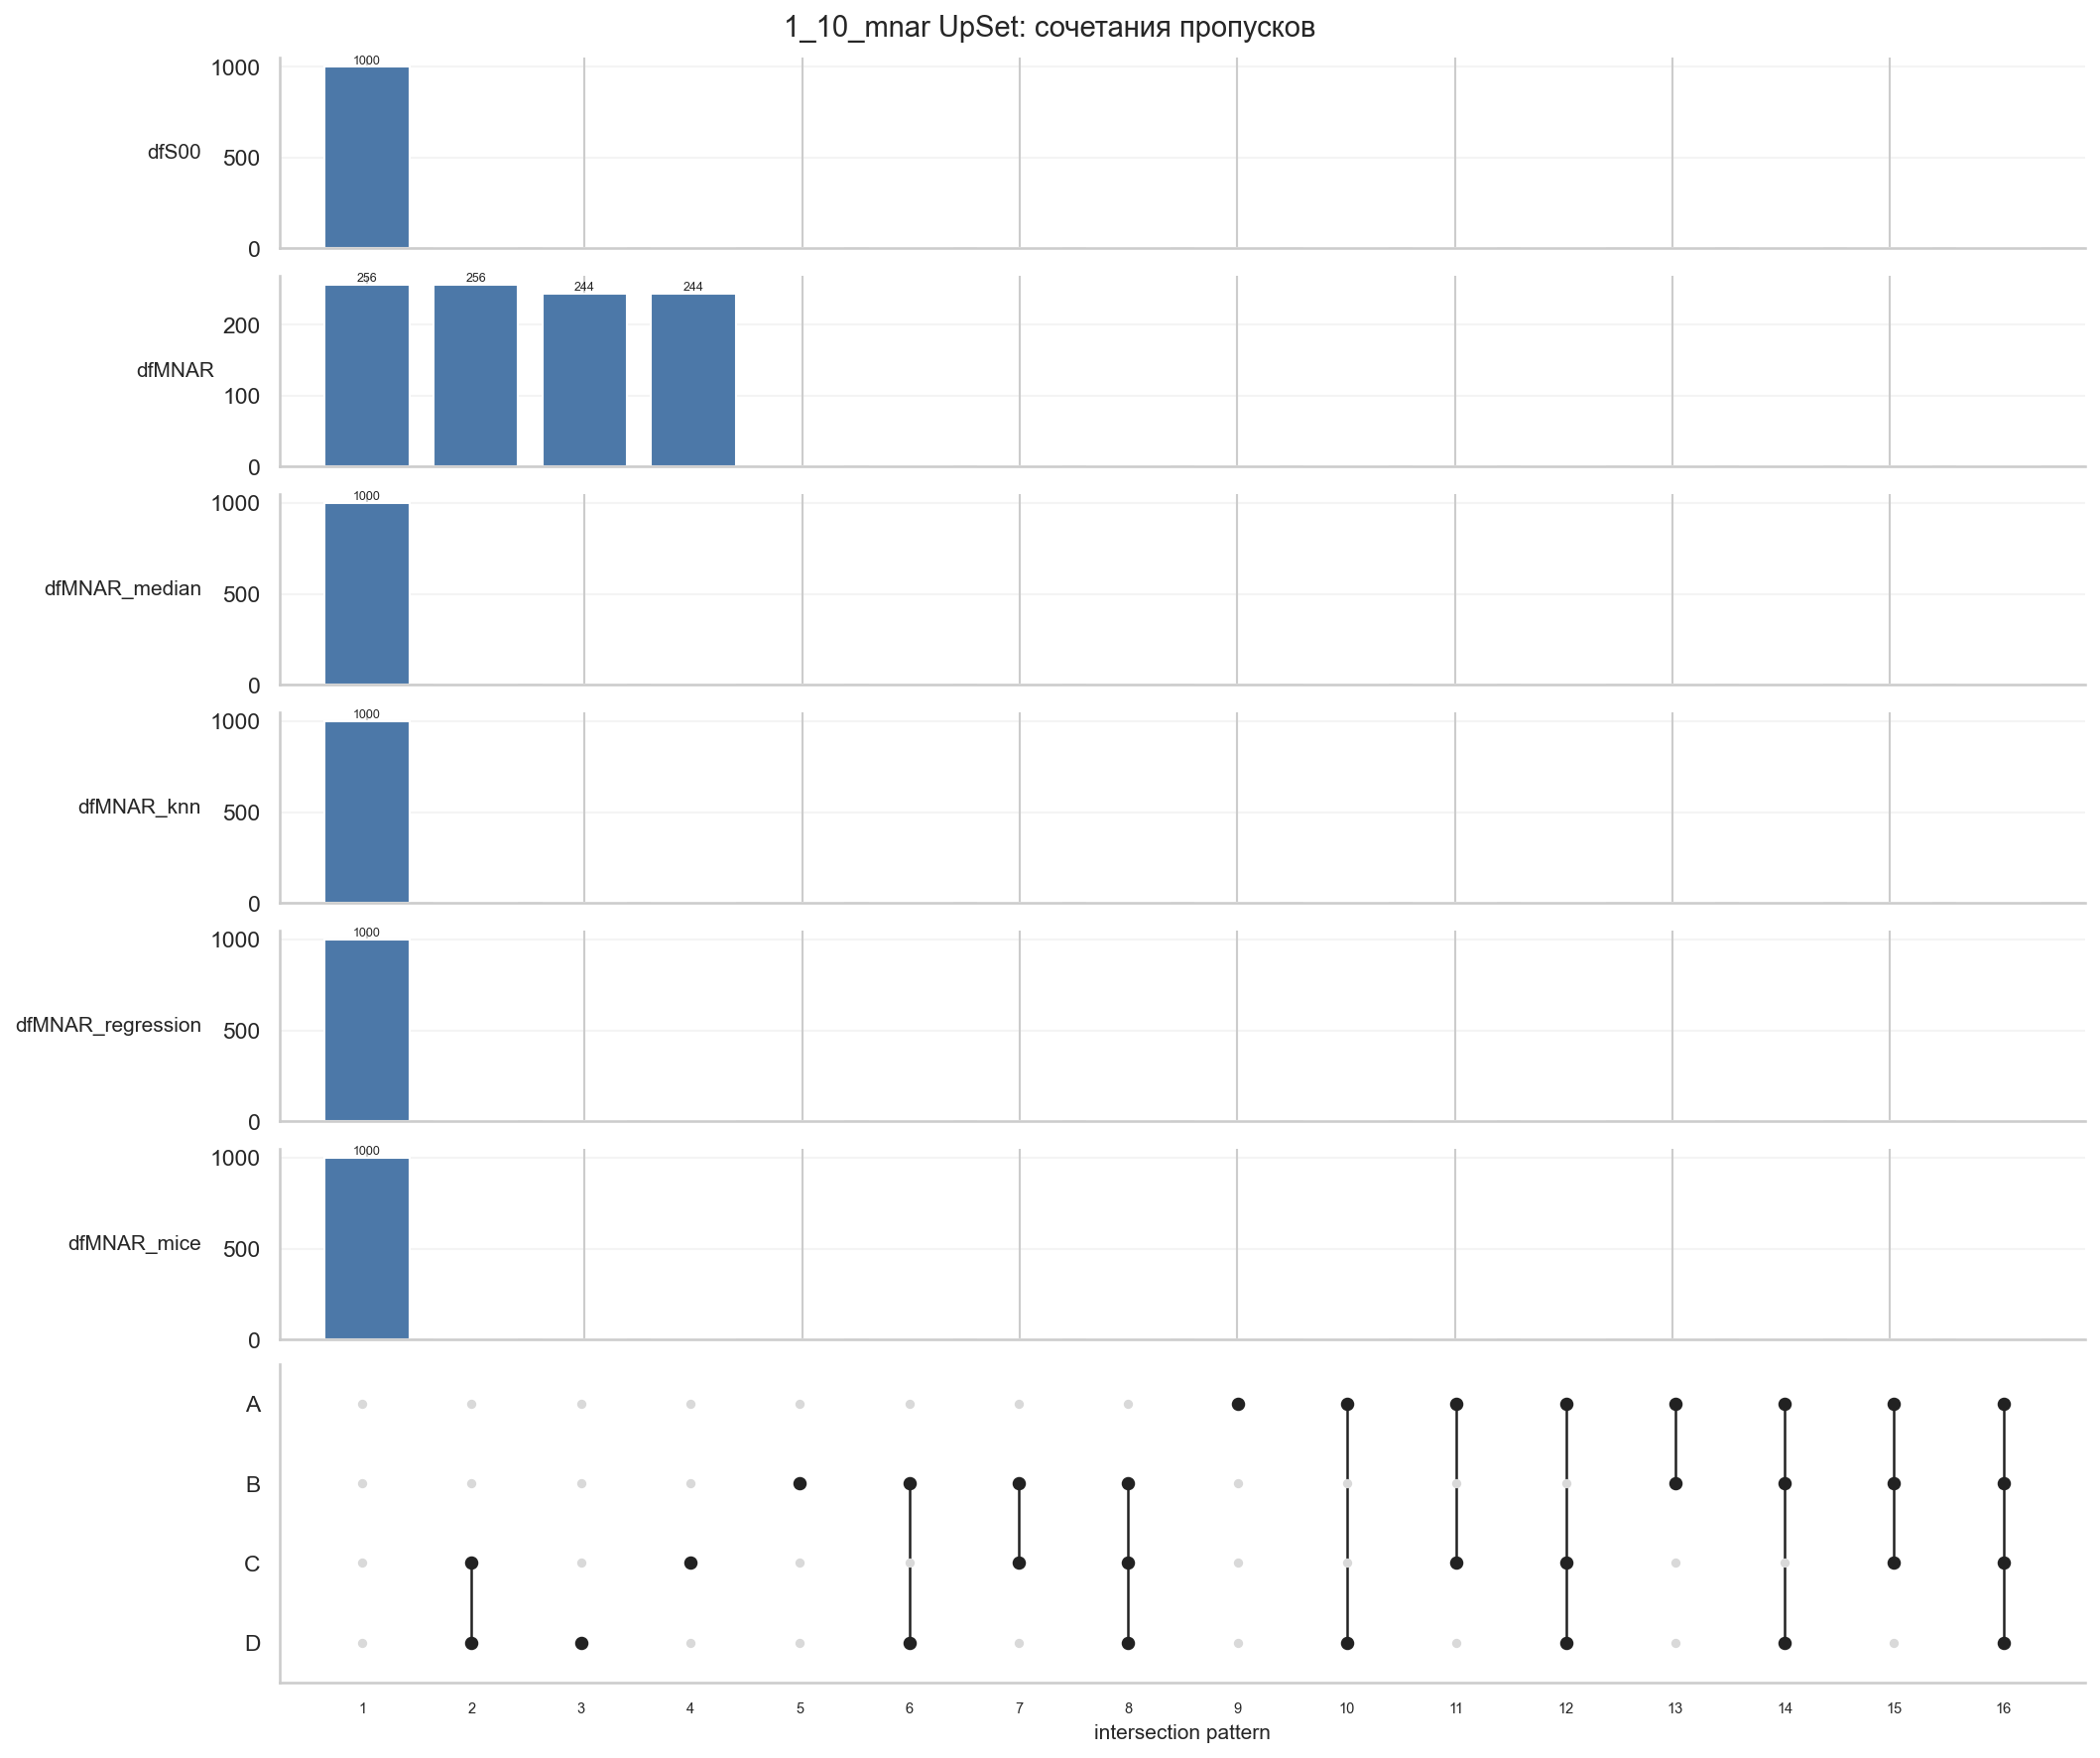

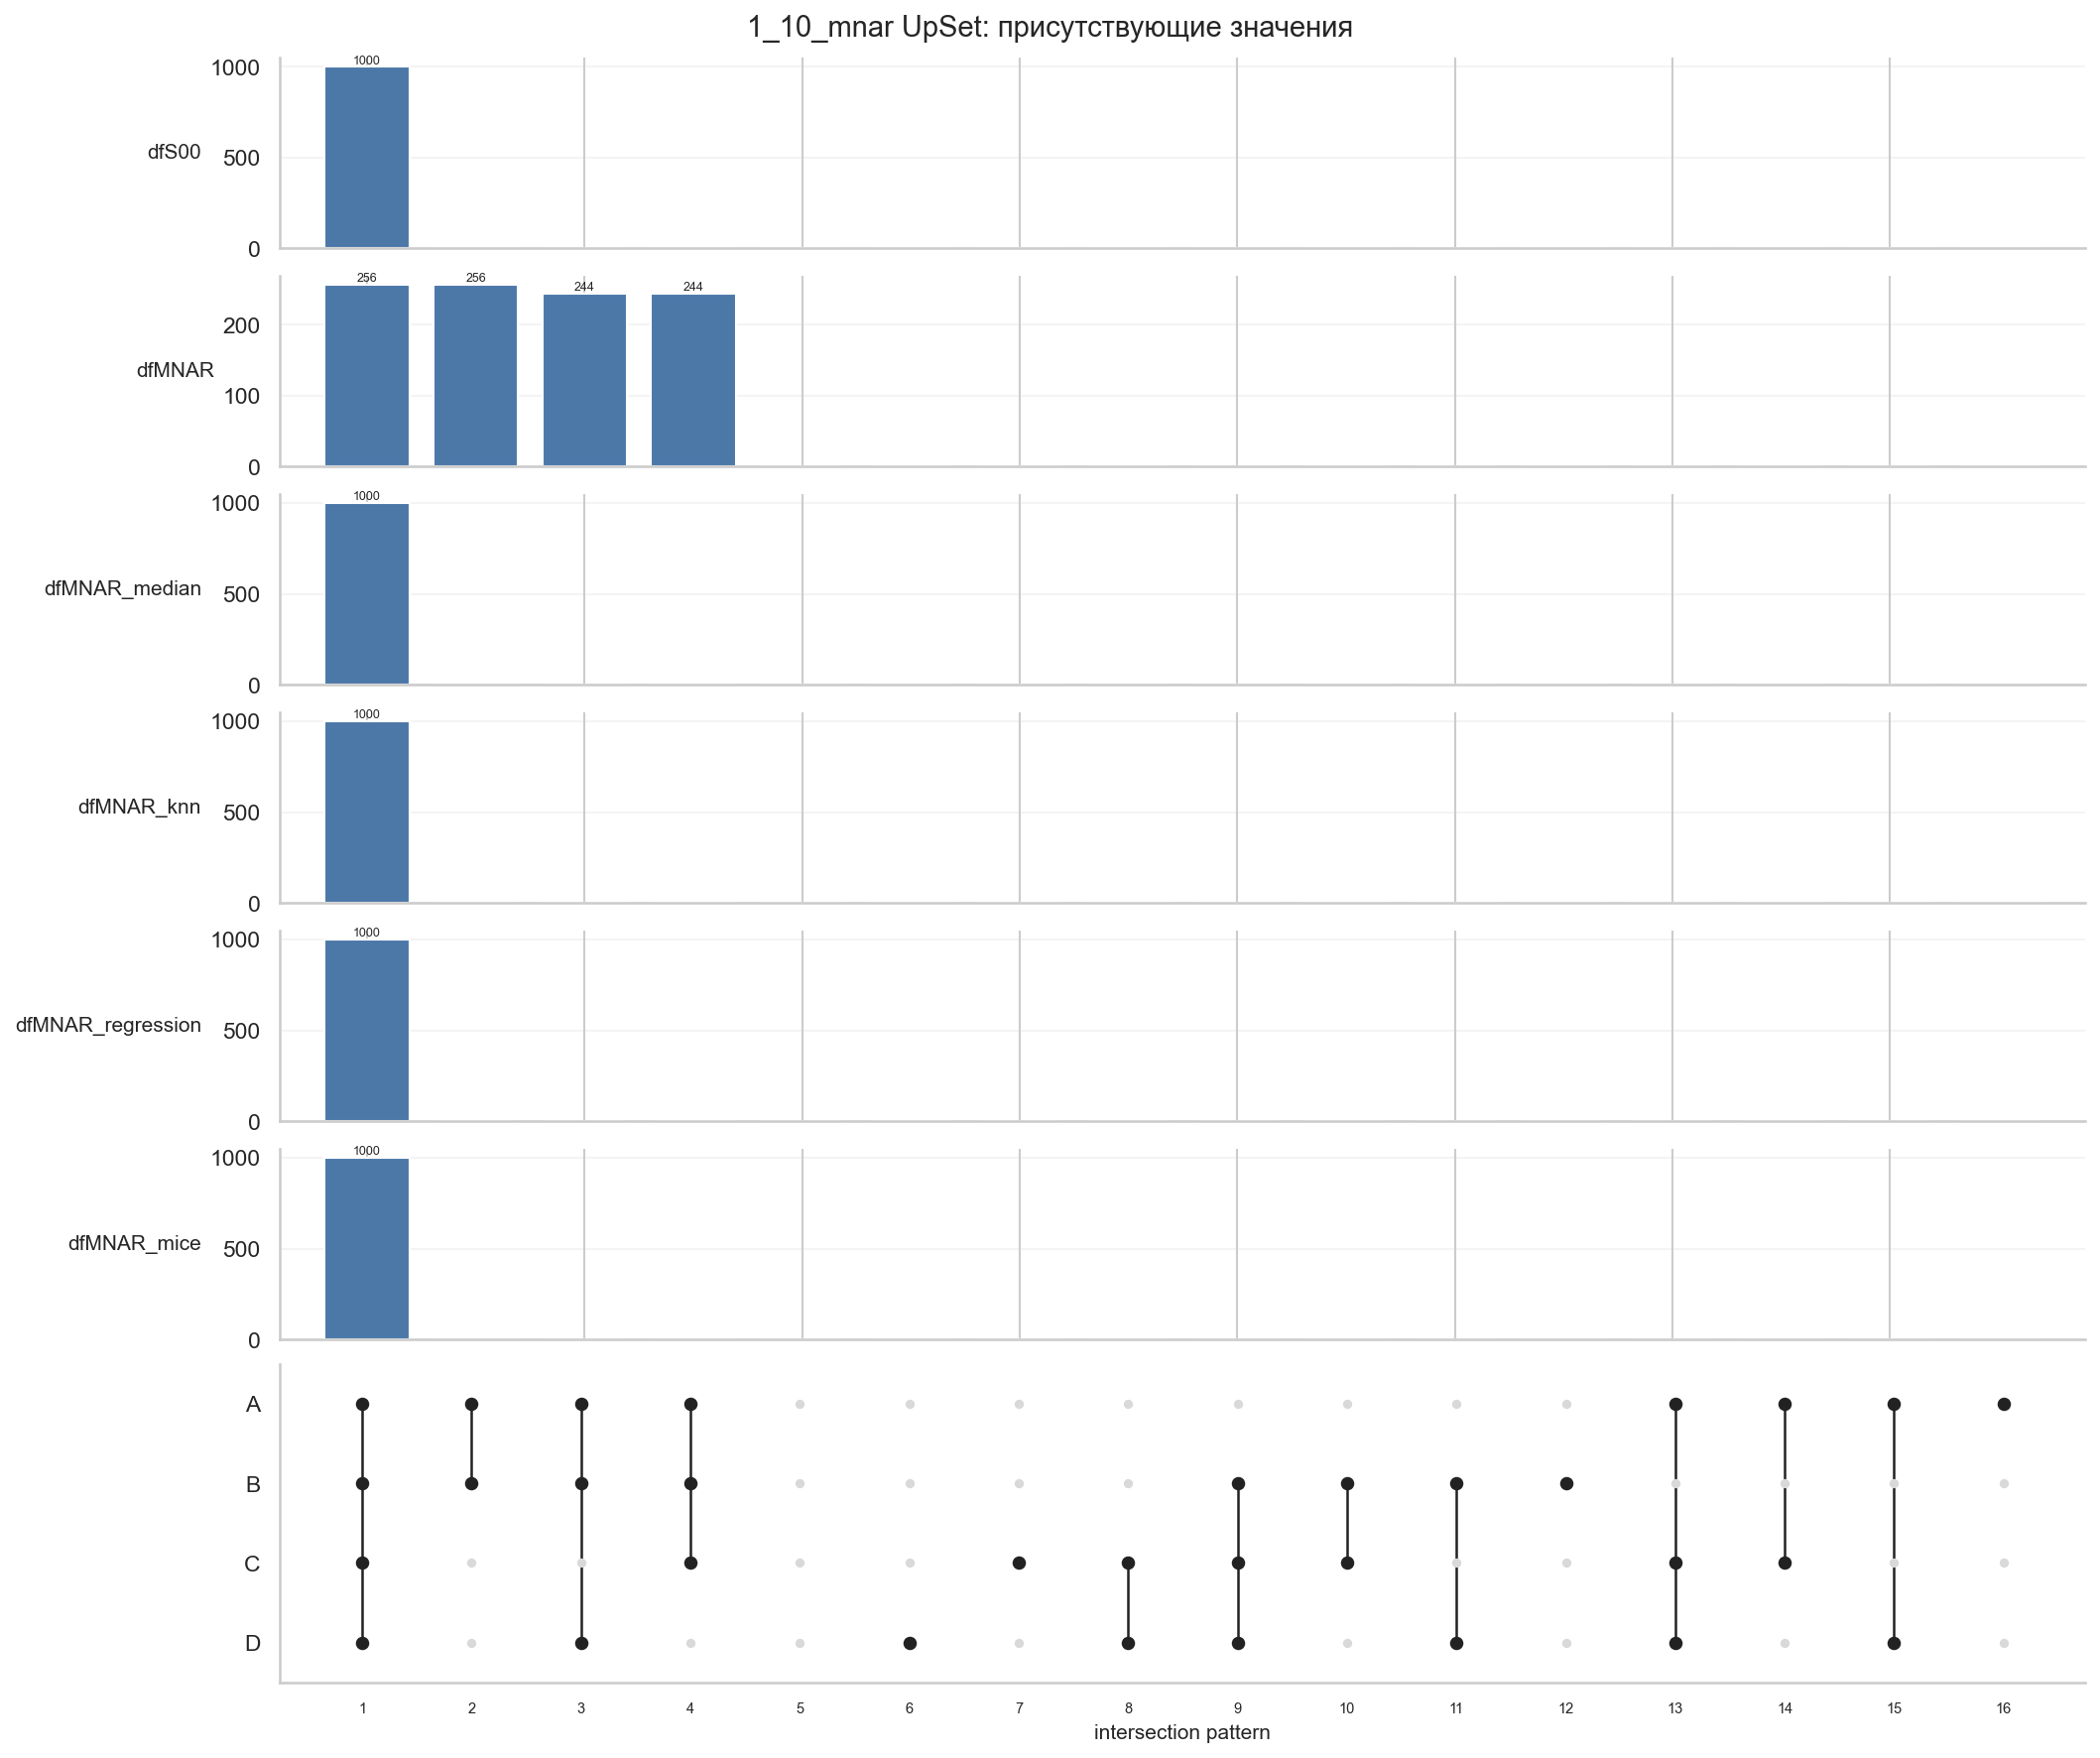

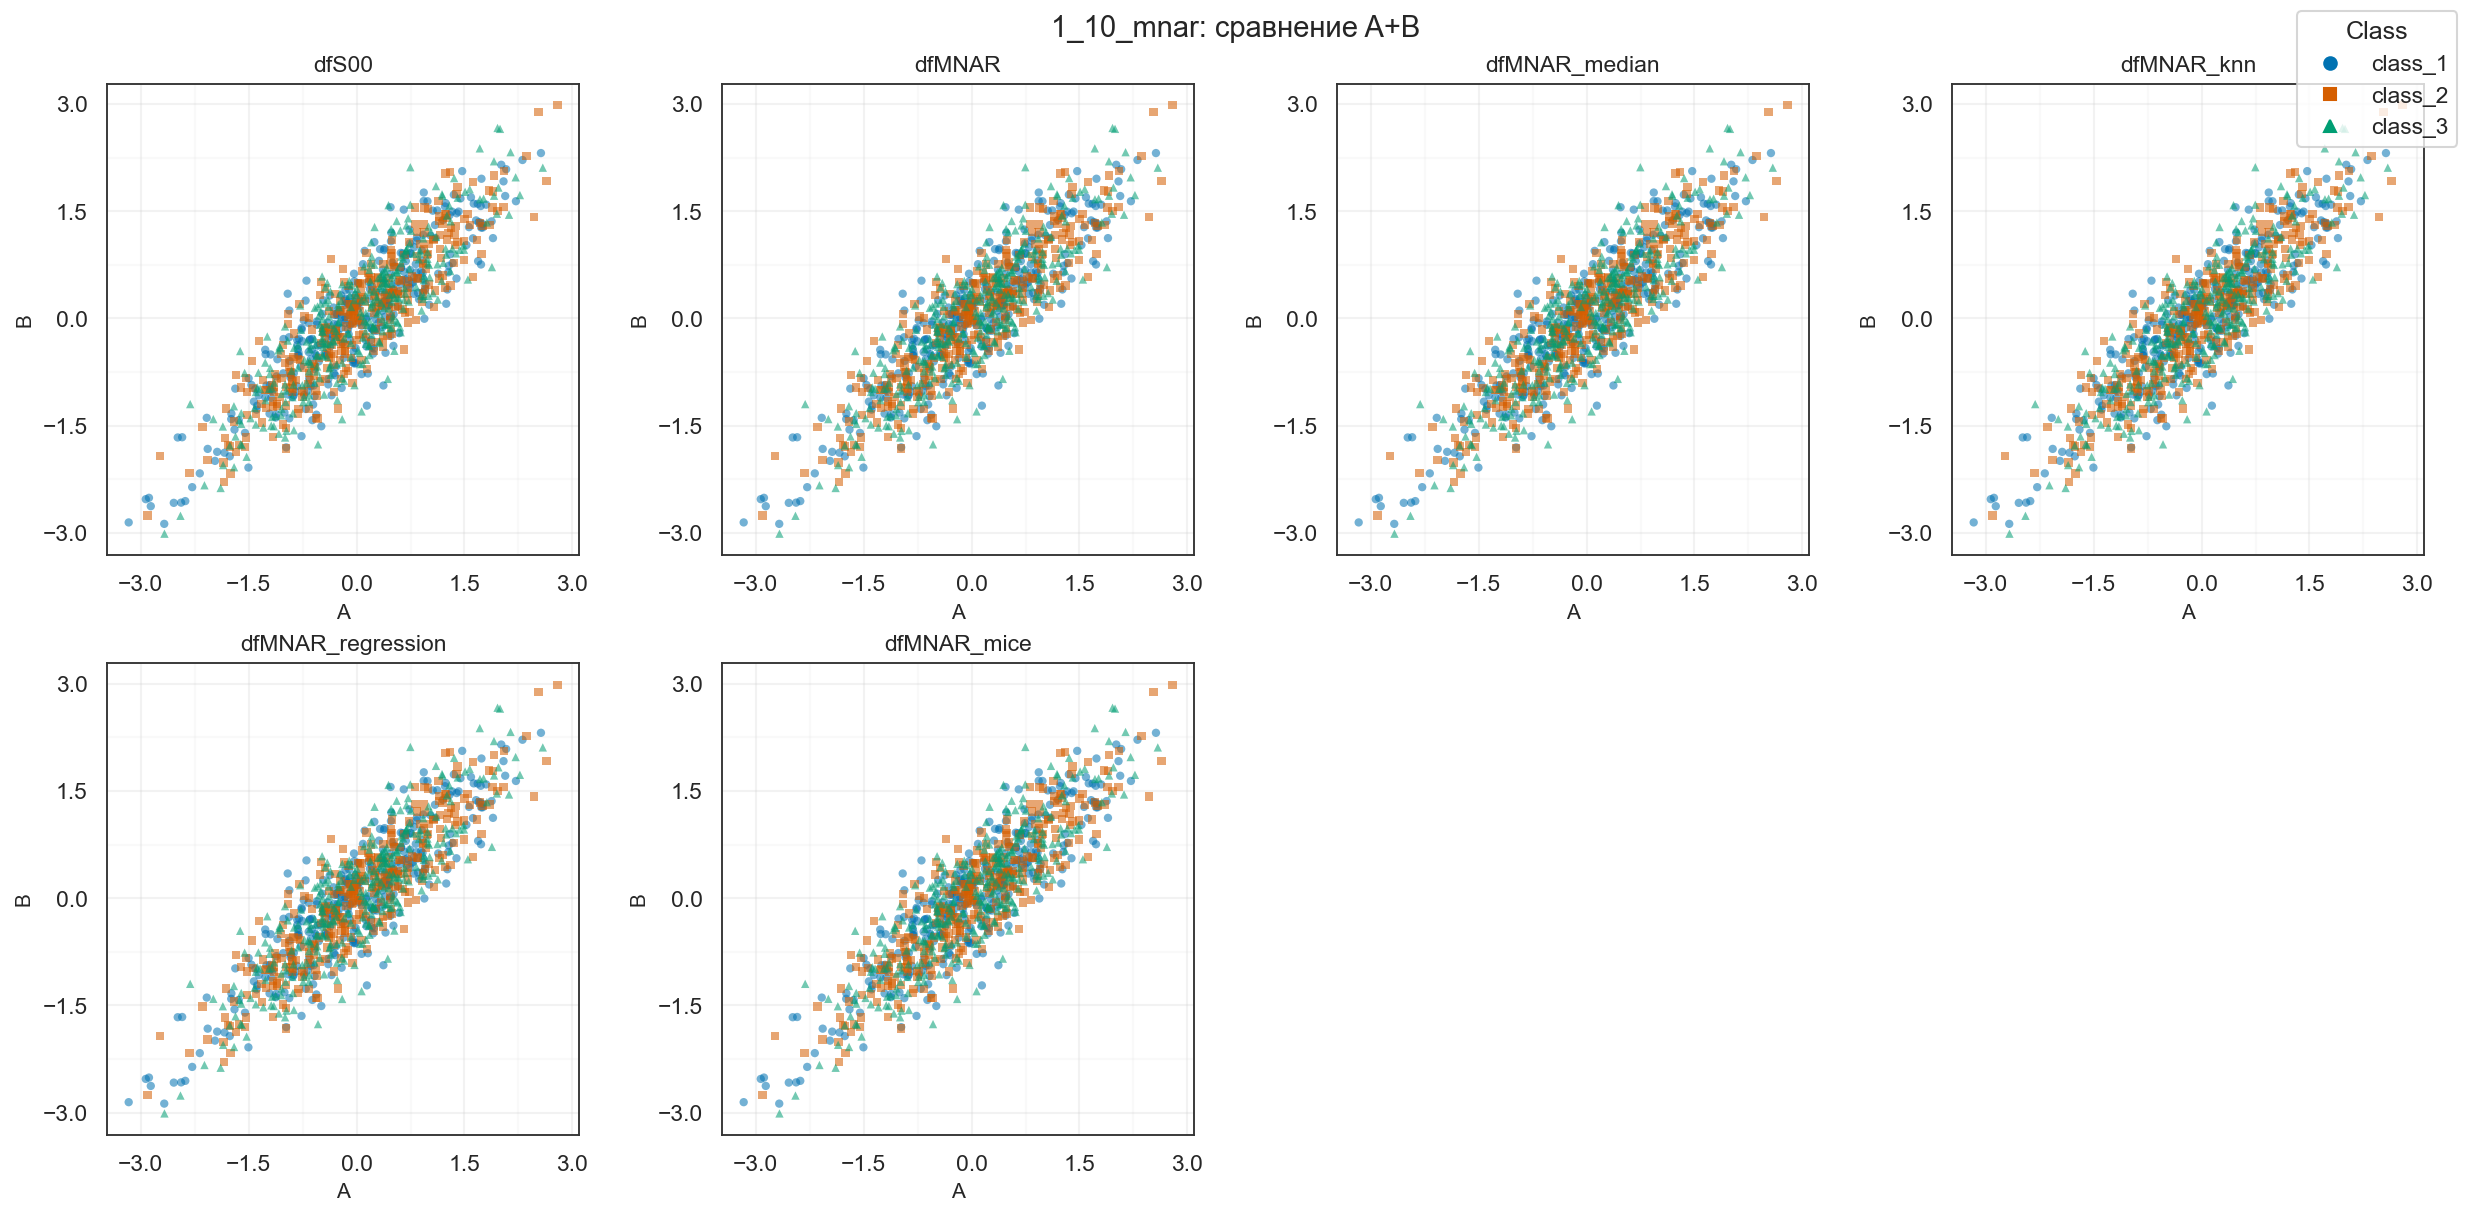

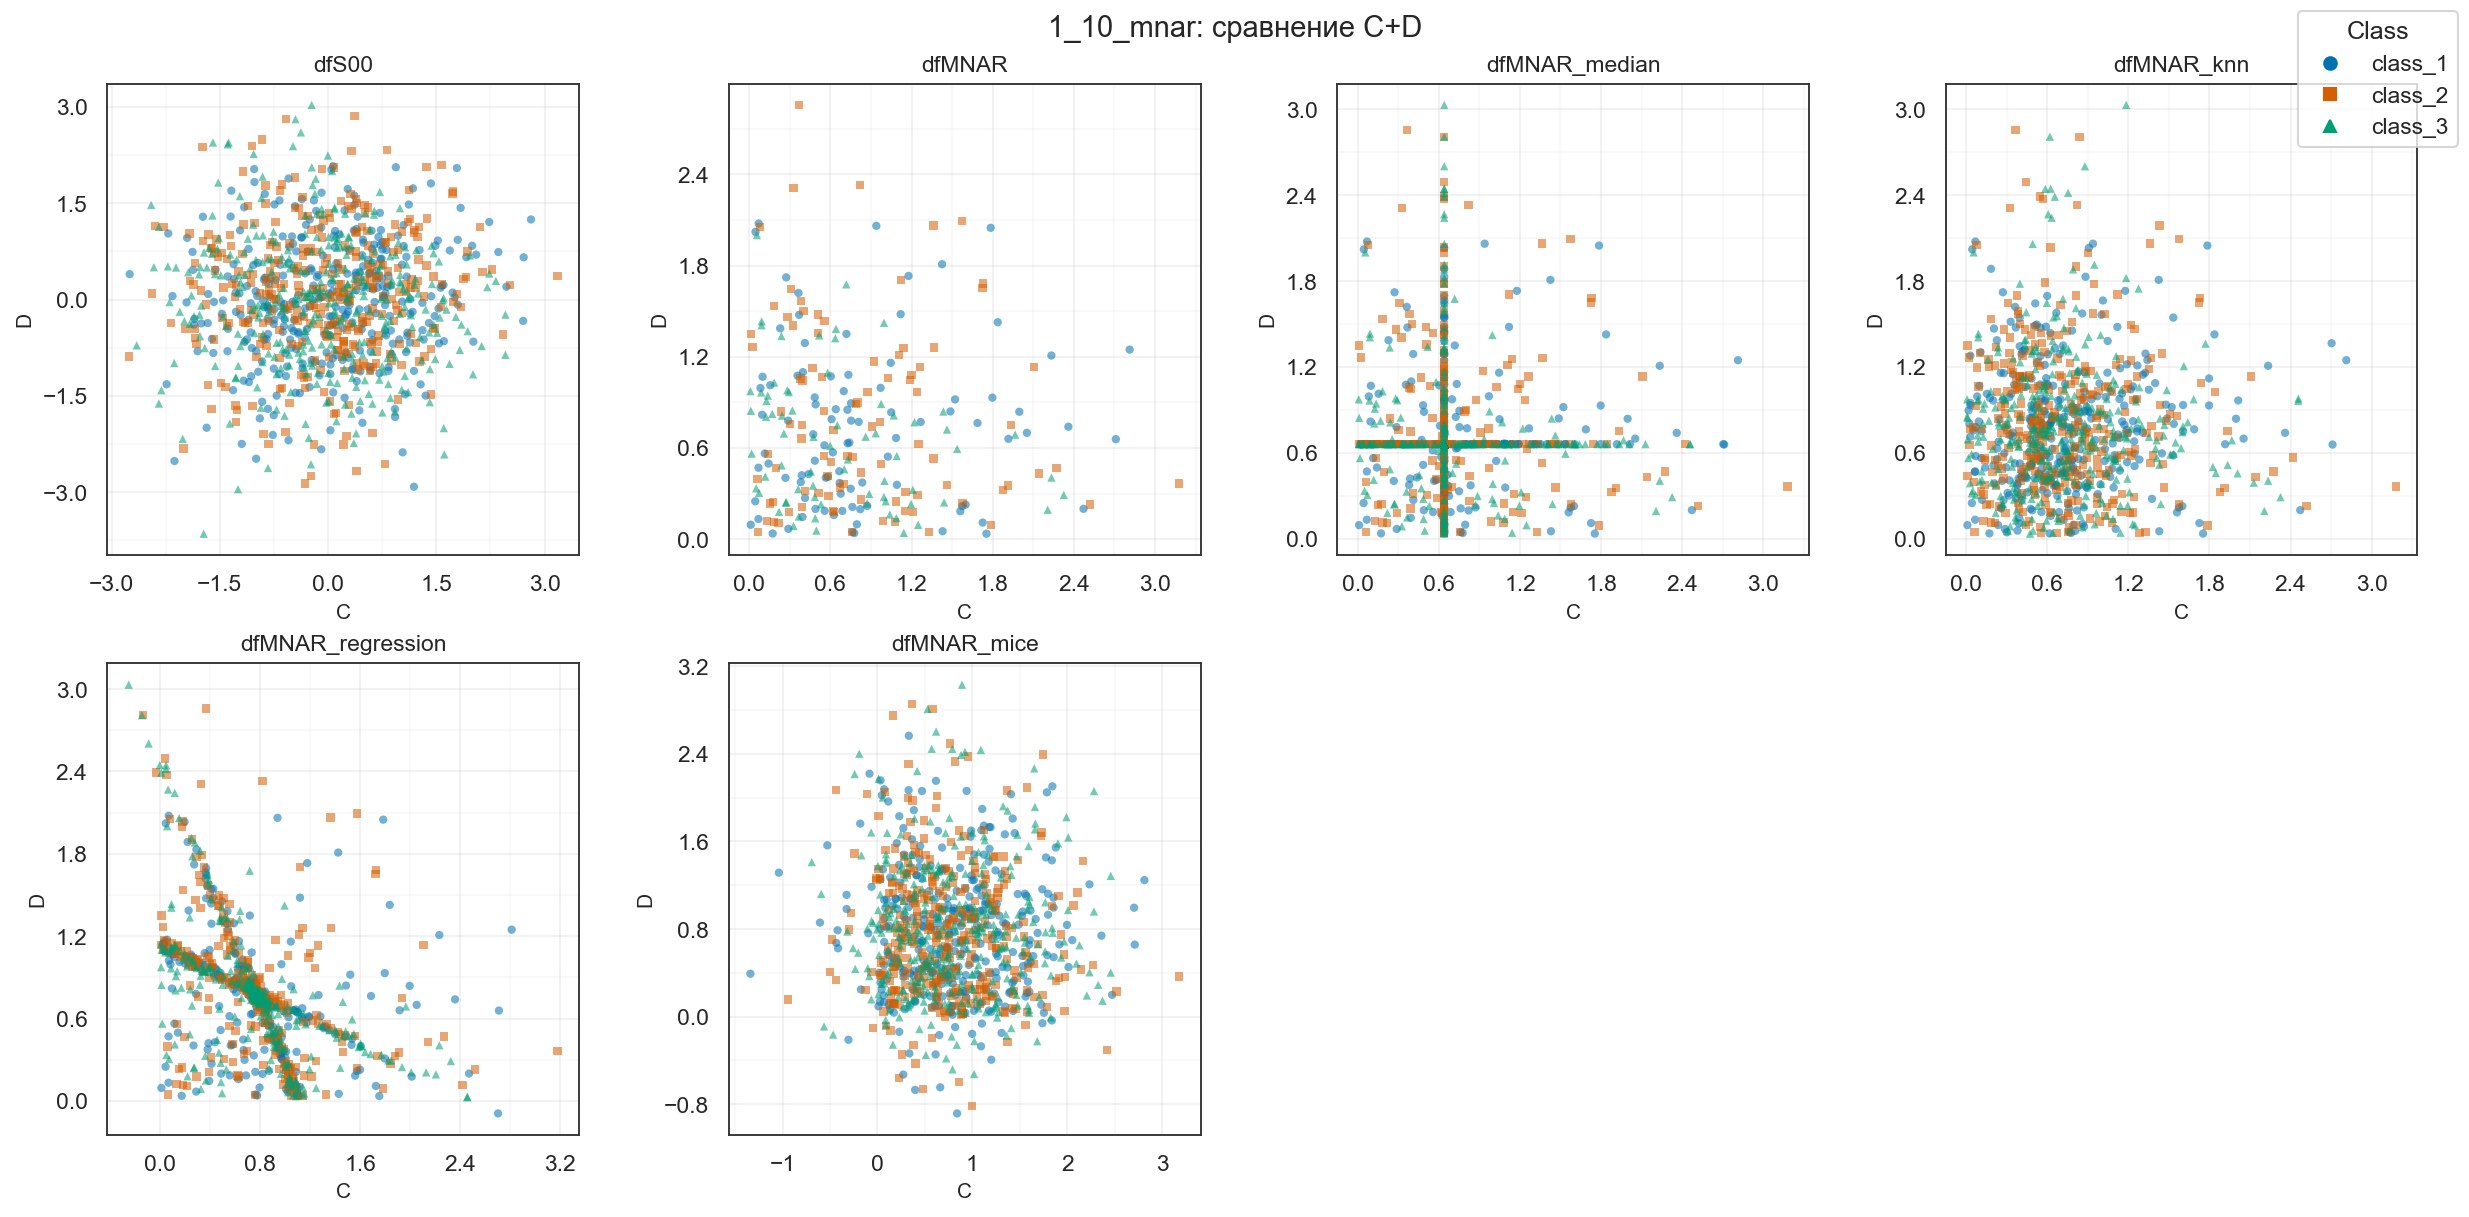

In [38]:
# [1.10]
dfMNAR = inject_mnar(dfS00)
dfMNAR.to_csv(output_dir / "data" / "dfMNAR.csv", index=False)
mnar_comparison = comparison_workflow(
    base_df=dfS00,
    missing_df=dfMNAR,
    base_name="dfS00",
    missing_name="dfMNAR",
    output_dir=output_dir,
    style=style,
    random_state=seed,
    knn_neighbors=knn_neighbors,
    pair1=pair1,
    pair2=pair2,
    task_prefix="1_10_mnar",
)
